# 06. Peer Benchmark Analysis — 황학동 4개 상권의 구조적 유사 상권 비교

`05_commercial_signal.ipynb`에서 서울 전체 상권에 대해 direction / structural change / decoupling / instability /
change intensity signal과 Isolation Forest anomaly, KMeans typology를 구축했다. 이번 노트북은 **새로운 예측 모델을
만들지 않는다.** 대신 05의 결과를 **peer benchmark와 비교 진단**에 활용한다.

## 분석 질문

- **Q1.** 황학동 4개 상권 각각과 구조적으로 가장 유사한 서울 상권은 어디인가?
- **Q2.** 황학동은 비슷한 구조의 상권과 비교했을 때 매출/거래/유동인구/점포 변화, 업종 구조, 시간대 소비 구조,
  변화 강도, 이상성 측면에서 무엇이 다른가?
- **Q3.** 황학동의 현재 변화가 서울 전체에서도 흔한 현상인지, 비슷한 조건의 상권과 비교해도 특이한 현상인지 구분할 수 있는가?
- **Q4.** 각 황학동 상권에 대해 향후 활성화 전략을 설계할 때 참고할 수 있는 benchmark peer는 무엇인가?

## 핵심 설계 원칙

Peer를 찾을 때 05에서 만든 **변화 signal(direction/structural_change/decoupling/instability/change_intensity/
anomaly/cluster)을 peer selection feature로 사용하지 않는다.** 이 변수들은 peer를 찾은 *뒤에* 비교할
outcome/diagnosis 변수로만 사용한다.

```text
상권의 기본 구조·규모로 peer 선정  ->  05의 변화 signal로 peer와 비교  ->  황학동만의 상대적 차이 진단
```


## 1. 라이브러리 및 설정

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import RobustScaler
from sklearn.neighbors import NearestNeighbors

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

PROCESSED_DIR = Path("../data/processed")
FEATURES_PATH = PROCESSED_DIR / "commercial_features.csv"
SIGNALS_PATH = PROCESSED_DIR / "commercial_signals.csv"
TYPOLOGY_PATH = PROCESSED_DIR / "latest_commercial_typology.csv"
FEATURE_DICT_PATH = PROCESSED_DIR / "feature_dictionary.csv"
SIGNAL_DICT_PATH = PROCESSED_DIR / "signal_dictionary.csv"

MATCHES_OUT_PATH = PROCESSED_DIR / "hwanghak_peer_matches.csv"
BENCHMARK_OUT_PATH = PROCESSED_DIR / "hwanghak_peer_benchmark.csv"
BENCHMARK_DICT_OUT_PATH = PROCESSED_DIR / "peer_benchmark_dictionary.csv"
ROBUSTNESS_OUT_PATH = PROCESSED_DIR / "hwanghak_peer_robustness.csv"

for name, p in [
    ("FEATURES_PATH", FEATURES_PATH), ("SIGNALS_PATH", SIGNALS_PATH),
    ("TYPOLOGY_PATH", TYPOLOGY_PATH), ("FEATURE_DICT_PATH", FEATURE_DICT_PATH),
    ("SIGNAL_DICT_PATH", SIGNAL_DICT_PATH),
]:
    print(f"{name:18s} {p} -> exists: {p.exists()}")

FEATURES_PATH      ..\data\processed\commercial_features.csv -> exists: True
SIGNALS_PATH       ..\data\processed\commercial_signals.csv -> exists: True
TYPOLOGY_PATH      ..\data\processed\latest_commercial_typology.csv -> exists: True
FEATURE_DICT_PATH  ..\data\processed\feature_dictionary.csv -> exists: True
SIGNAL_DICT_PATH   ..\data\processed\signal_dictionary.csv -> exists: True


In [2]:
# 03/04/05와 동일한 스타일의 그래프 설정
sns.set_theme(style="whitegrid")

_KOREAN_FONT_CANDIDATES = [
    "Malgun Gothic", "AppleGothic", "NanumGothic", "NanumBarunGothic",
    "Noto Sans CJK KR", "Noto Sans KR", "Gulim",
]
_available_fonts = {f.name for f in fm.fontManager.ttflist}
_font_name = next((c for c in _KOREAN_FONT_CANDIDATES if c in _available_fonts), None)

if _font_name:
    plt.rcParams["font.family"] = _font_name
    print(f"한글 폰트 설정: {_font_name}")
else:
    print("경고: 사용 가능한 한글 폰트를 찾지 못했습니다. 그래프의 한글 라벨이 깨질 수 있습니다.")

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["mathtext.fontset"] = "dejavusans"

import logging
logging.getLogger("matplotlib").setLevel(logging.ERROR)
plt.rcParams["figure.dpi"] = 100

HWANGHAK_COLOR = "#C0392B"
PEER_COLOR = "#2E86AB"
SEOUL_TYPE_COLOR = "#7F8C8D"

한글 폰트 설정: Malgun Gothic


## 2. 데이터 로드

In [3]:
features = pd.read_csv(FEATURES_PATH, encoding="utf-8-sig")
signals = pd.read_csv(SIGNALS_PATH, encoding="utf-8-sig")
typology = pd.read_csv(TYPOLOGY_PATH, encoding="utf-8-sig")
feature_dictionary = pd.read_csv(FEATURE_DICT_PATH, encoding="utf-8-sig")
signal_dictionary = pd.read_csv(SIGNAL_DICT_PATH, encoding="utf-8-sig")

print("features  shape:", features.shape)
print("signals   shape:", signals.shape)
print("typology  shape:", typology.shape)
print("feature_dictionary shape:", feature_dictionary.shape)
print("signal_dictionary  shape:", signal_dictionary.shape)

features  shape: (33000, 81)
signals   shape: (33000, 55)
typology  shape: (1650, 17)
feature_dictionary shape: (75, 5)
signal_dictionary  shape: (33, 5)


## 3. 데이터 및 grain 검증

`04`/`05`와 동일하게 `(기준_년분기_코드, 상권_코드)`가 grain임을 재확인한다. `features`와 `signals`는
2021Q1~2025Q4(20개 분기) x 1,650개 서울 상권 = 33,000행이고, `typology`는 05에서 만든 **최신 분기 단면**
(1,650행)이다.

In [4]:
for df, name, expected_rows in [(features, "features", 33000), (signals, "signals", 33000)]:
    assert not df.duplicated(subset=["기준_년분기_코드", "상권_코드"]).any(), f"{name} grain에 중복이 있습니다."
    assert df.shape[0] == expected_rows, f"{name} 행 수가 예상과 다릅니다: {df.shape[0]}"
    assert df["상권_코드"].nunique() == 1650
    assert df["기준_년분기_코드"].nunique() == 20

assert typology["상권_코드"].nunique() == typology.shape[0] == 1650, "typology는 최신 분기 단면(1650행)이어야 합니다."
assert typology["기준_년분기_코드"].nunique() == 1, "typology에 여러 분기가 섞여 있습니다."

print("grain 검증 통과.")
print("features/signals 분기 범위:", features["기준_년분기_코드"].min(), "~", features["기준_년분기_코드"].max())
print("typology 기준 분기:", int(typology["기준_년분기_코드"].iloc[0]))

grain 검증 통과.
features/signals 분기 범위: 20211 ~ 20254
typology 기준 분기: 20254


## 4. 유틸리티 함수

`05`와 동일한 유틸리티(분기 라벨 변환)를 재사용한다.

In [5]:
def to_quarter_label(code_):
    code_ = int(code_)
    year, q = divmod(code_, 10)
    return f"{year}Q{q}"


QUARTER_ORDER = sorted(features["기준_년분기_코드"].unique().tolist())
QUARTER_LABELS = [to_quarter_label(q) for q in QUARTER_ORDER]
QUARTER_LABEL_MAP = dict(zip(QUARTER_ORDER, QUARTER_LABELS))
LATEST_QUARTER = QUARTER_ORDER[-1]

print("LATEST_QUARTER =", LATEST_QUARTER, f"({QUARTER_LABEL_MAP[LATEST_QUARTER]})")
print("typology 기준 분기와 일치 여부:", LATEST_QUARTER == int(typology["기준_년분기_코드"].iloc[0]))

LATEST_QUARTER = 20254 (2025Q4)
typology 기준 분기와 일치 여부: True


## 5. 황학동 4개 상권 확인 (target 정의)

상권명을 하드코딩해 가정하지 않고, `상권_코드_명`에 `'황학'`이 포함된 상권을 최신 분기 데이터에서 직접 조회해
04/05와 동일한 4개 상권인지 확인한다.

In [6]:
hwanghak_lookup = features.loc[
    features["기준_년분기_코드"] == LATEST_QUARTER,
    ["상권_코드", "상권_코드_명", "상권_구분_코드", "상권_구분_코드_명"],
].drop_duplicates()
hwanghak_lookup = hwanghak_lookup[hwanghak_lookup["상권_코드_명"].str.contains("황학")]

print("상권_코드_명에 '황학'을 포함하는 상권(최신 분기 기준):")
print(hwanghak_lookup.to_string(index=False))

HWANGHAK_CODES = sorted(hwanghak_lookup["상권_코드"].astype(int).tolist())
assert len(HWANGHAK_CODES) == 4, f"황학동 상권이 4개가 아닙니다: {HWANGHAK_CODES}"
assert set(HWANGHAK_CODES).issubset(set(features["상권_코드"].unique()))

HWANGHAK_NAME_MAP = dict(zip(hwanghak_lookup["상권_코드"], hwanghak_lookup["상권_코드_명"]))
HWANGHAK_TYPE_MAP = dict(zip(hwanghak_lookup["상권_코드"], hwanghak_lookup["상권_구분_코드_명"]))

print("\nHWANGHAK_CODES =", HWANGHAK_CODES)
for c in HWANGHAK_CODES:
    print(f"  {c}: {HWANGHAK_NAME_MAP[c]} ({HWANGHAK_TYPE_MAP[c]})")

상권_코드_명에 '황학'을 포함하는 상권(최신 분기 기준):
  상권_코드             상권_코드_명 상권_구분_코드 상권_구분_코드_명
3110055             황학동벼룩시장        A       골목상권
3110057            황학코아루아파트        A       골목상권
3130054        황학동주방가구거리상점가        R       전통시장
3130055 황학시장(서울중앙시장, 신중앙시장)        R       전통시장

HWANGHAK_CODES = [3110055, 3110057, 3130054, 3130055]
  3110055: 황학동벼룩시장 (골목상권)
  3110057: 황학코아루아파트 (골목상권)
  3130054: 황학동주방가구거리상점가 (전통시장)
  3130055: 황학시장(서울중앙시장, 신중앙시장) (전통시장)


## 6. Peer 후보군 정의 원칙

황학동과 무관한 서울 상권 전체를 무조건 같은 후보군으로 두지 않는다. `상권_구분_코드_명`(골목상권/전통시장/발달상권/
관광특구)이 이미 존재하므로, 각 황학동 상권의 peer 후보군은 **동일 상권유형의 서울 상권(황학동 4개 제외)** 으로
제한한다. 황학동 4개 상권은 골목상권 2개, 전통시장 2개에 속하므로 이 두 유형 각각에 대해 별도의 reference pool을
구성한다.

In [7]:
LATEST_TYPE_COUNTS = features.loc[features["기준_년분기_코드"] == LATEST_QUARTER, "상권_구분_코드_명"].value_counts()
print("최신 분기 서울 상권 유형별 개수:")
print(LATEST_TYPE_COUNTS)

TARGET_TYPES = sorted(set(HWANGHAK_TYPE_MAP.values()))
print("\n황학동 4개 상권이 속한 상권유형:", TARGET_TYPES)
print("각 유형은 같은 유형의 서울 상권(황학동 제외)만 peer 후보군으로 사용한다.")

최신 분기 서울 상권 유형별 개수:
상권_구분_코드_명
골목상권    1090
전통시장     305
발달상권     249
관광특구       6
Name: count, dtype: int64

황학동 4개 상권이 속한 상권유형: ['골목상권', '전통시장']
각 유형은 같은 유형의 서울 상권(황학동 제외)만 peer 후보군으로 사용한다.


## 7. 분석 기준 시점 및 baseline feature 설계 원칙

Peer matching은 **최신 분기**(`LATEST_QUARTER`, 2025Q4) 시점을 기준으로 수행하되, peer selection에 사용하는
구조 feature 자체에는 **2025Q4를 포함하지 않는다.** 최종적으로 비교하는 outcome(YoY, 05의 change signal) 역시
2025Q4 기준이므로, peer selection feature에 2025Q4가 섞이면 "분석 대상 분기의 변화"가 peer를 고르는 기준 자체에
스며드는 문제가 있다.

> Peer는 분석 대상 분기의 outcome을 보지 않고, 직전 4개 분기의 규모 및 구조적 특성만을 이용해 선정한다.
> 이를 통해 분석 대상 분기의 급격한 변화가 peer selection 자체에 영향을 주는 것을 방지한다.

```text
Peer selection:  2024Q4 ~ 2025Q3 (2025Q4 이전 4개 분기)의 구조적 특성만 사용
Outcome / 진단:   2025Q4의 변화 signal 및 YoY로 peer와 비교
```

- **절대 규모(매출/유동인구/점포수)**: 04에서 만든 `sales_4q_mean` 등은 이미 "당분기 포함" trailing 4Q 평균이므로,
  `groupby("상권_코드")["sales_4q_mean"].shift(1)`로 한 분기만 밀면 2025Q4 시점에서 2024Q4~2025Q3 평균이 된다.
- **소비/업종 구조 비중**: 04에는 4분기 평균 버전이 없으므로 이 노트북에서 직접 계산한다. `shift(1)` 후
  `rolling(4, min_periods=4).mean()`을 적용하면, 2025Q4 행에는 2024Q4~2025Q3 4개 분기만 반영되고 2025Q4
  당분기 값은 포함되지 않는다.

DTW 등 복잡한 time-series matching은 사용하지 않는다 -- `shift` + `rolling`만으로 "분석 대상 분기 정보를 peer
selection에서 제외"라는 목적은 충분히 달성된다. 실제로 어떤 4개 분기가 사용됐는지는 아래에서 출력하고, 독립적으로
재계산한 값과 비교해 assert로 교차검증한다.

In [8]:
STRUCTURE_BASELINE_SRC_COLS = [
    "weekend_sales_share", "evening_night_sales_share",
    "industry_hhi", "top1_industry_share", "active_industry_count",
]
SCALE_BASELINE_SRC_COLS = ["sales_4q_mean", "population_4q_mean", "store_4q_mean"]

baseline = features.sort_values(["상권_코드", "기준_년분기_코드"]).reset_index(drop=True).copy()

# 소비/업종 구조: 당분기를 제외하기 위해 먼저 1분기 shift한 뒤 4분기 rolling mean을 취한다.
# t행 기준 shift(1).rolling(4)는 (t-4)~(t-1) 분기만 사용하고 t분기(비교 대상 outcome 분기)는 포함하지 않는다.
for col in STRUCTURE_BASELINE_SRC_COLS:
    baseline[f"{col}_4q_avg"] = baseline.groupby("상권_코드")[col].transform(
        lambda s: s.shift(1).rolling(4, min_periods=4).mean()
    )

# 규모 변수: sales_4q_mean 등은 이미 당분기 포함 trailing 4Q 평균이므로, 1분기만 shift하면
# (t-4)~(t-1) 분기 평균이 된다. `_baseline` 접미사로 2025Q4 당분기 현재값(원본 컬럼명)과 명확히 구분한다.
for col in SCALE_BASELINE_SRC_COLS:
    baseline[f"{col}_baseline"] = baseline.groupby("상권_코드")[col].shift(1)

baseline_latest = baseline[baseline["기준_년분기_코드"] == LATEST_QUARTER].copy()

print("[규모 변수 skewness 확인 -- log1p 적용 근거 (2025Q4 시점 baseline 값 기준)]")
for col in SCALE_BASELINE_SRC_COLS:
    base_col = f"{col}_baseline"
    raw_skew = baseline_latest[base_col].dropna().skew()
    log_skew = np.log1p(baseline_latest[base_col].dropna()).skew()
    print(f"  {col:22s} skew(raw)={raw_skew:6.2f}  ->  skew(log1p)={log_skew:6.2f}")
    baseline_latest[f"log_{col}"] = np.log1p(baseline_latest[base_col])

BASELINE_COLS = (
    [f"log_{c}" for c in SCALE_BASELINE_SRC_COLS]
    + [f"{c}_4q_avg" for c in STRUCTURE_BASELINE_SRC_COLS]
)

# --- baseline이 실제로 어느 분기를 사용했는지 확인 ---
latest_pos = QUARTER_ORDER.index(LATEST_QUARTER)
BASELINE_QUARTERS = QUARTER_ORDER[latest_pos - 4: latest_pos]
assert len(BASELINE_QUARTERS) == 4, "직전 4개 분기를 모두 확보하지 못했습니다."
assert LATEST_QUARTER not in BASELINE_QUARTERS, "baseline 분기에 분석 대상 분기(LATEST_QUARTER)가 포함되어 있습니다."
print(f"\n{QUARTER_LABEL_MAP[LATEST_QUARTER]} peer selection baseline이 사용하는 분기: "
      f"{[QUARTER_LABEL_MAP[q] for q in BASELINE_QUARTERS]}")

# 규모 변수 baseline이 실제로 직전 분기(2025Q3) 시점의 sales_4q_mean 등과 일치하는지 독립 검증
_prev_quarter = QUARTER_ORDER[latest_pos - 1]
_expected_scale = features[features["기준_년분기_코드"] == _prev_quarter].set_index("상권_코드")[SCALE_BASELINE_SRC_COLS]
_actual_scale = baseline_latest.set_index("상권_코드")[[f"{c}_baseline" for c in SCALE_BASELINE_SRC_COLS]]
_actual_scale.columns = SCALE_BASELINE_SRC_COLS
_diff_scale = (_expected_scale - _actual_scale).abs()
assert (_diff_scale.fillna(0) < 1e-6).all().all(), "baseline 규모 변수가 직전 분기 값과 일치하지 않습니다."
print(f"규모 변수 baseline이 {QUARTER_LABEL_MAP[_prev_quarter]} 시점의 sales_4q_mean 등과 정확히 일치함을 확인했습니다"
      f"(={QUARTER_LABEL_MAP[BASELINE_QUARTERS[0]]}~{QUARTER_LABEL_MAP[BASELINE_QUARTERS[-1]]} 평균).")

# 구조 변수(예: weekend_sales_share_4q_avg)가 직전 4개 분기 단순평균과 일치하는지 독립 재계산으로 교차검증
_check_col = "weekend_sales_share"
_expected_structure = (
    features[features["기준_년분기_코드"].isin(BASELINE_QUARTERS)]
    .groupby("상권_코드")[_check_col]
    .agg(lambda s: s.mean() if s.notna().all() else np.nan)
)
_actual_structure = baseline_latest.set_index("상권_코드")[f"{_check_col}_4q_avg"]
_diff_structure = (_expected_structure - _actual_structure).abs().dropna()
assert (_diff_structure < 1e-6).all(), f"{_check_col}_4q_avg가 직전 4개 분기 단순평균과 일치하지 않습니다."
print(f"{_check_col}_4q_avg가 {[QUARTER_LABEL_MAP[q] for q in BASELINE_QUARTERS]} 4개 분기 평균과 일치함을 확인했습니다.")

print(f"\n{QUARTER_LABEL_MAP[LATEST_QUARTER]} 기준 baseline feature 결측률(%):")
print((baseline_latest[BASELINE_COLS].isna().mean() * 100).round(2))

print("\n상권유형별 결측률(%):")
print((baseline_latest.groupby("상권_구분_코드_명")[BASELINE_COLS].apply(lambda d: d.isna().mean() * 100)).round(2))

hwanghak_baseline_na = baseline_latest[baseline_latest["상권_코드"].isin(HWANGHAK_CODES)][BASELINE_COLS].isna().sum().sum()
print(f"\n황학동 4개 상권의 baseline feature 결측 개수: {hwanghak_baseline_na}")
assert hwanghak_baseline_na == 0, "황학동 4개 상권의 baseline feature에 결측이 있습니다."

[규모 변수 skewness 확인 -- log1p 적용 근거 (2025Q4 시점 baseline 값 기준)]
  sales_4q_mean          skew(raw)= 11.12  ->  skew(log1p)= -0.30
  population_4q_mean     skew(raw)=  2.78  ->  skew(log1p)= -0.86
  store_4q_mean          skew(raw)=  9.55  ->  skew(log1p)=  0.17

2025Q4 peer selection baseline이 사용하는 분기: ['2024Q4', '2025Q1', '2025Q2', '2025Q3']
규모 변수 baseline이 2025Q3 시점의 sales_4q_mean 등과 정확히 일치함을 확인했습니다(=2024Q4~2025Q3 평균).
weekend_sales_share_4q_avg가 ['2024Q4', '2025Q1', '2025Q2', '2025Q3'] 4개 분기 평균과 일치함을 확인했습니다.

2025Q4 기준 baseline feature 결측률(%):
log_sales_4q_mean                   5.52
log_population_4q_mean              0.12
log_store_4q_mean                   0.00
weekend_sales_share_4q_avg          5.52
evening_night_sales_share_4q_avg    5.52
industry_hhi_4q_avg                 5.52
top1_industry_share_4q_avg          5.52
active_industry_count_4q_avg        5.52
dtype: float64

상권유형별 결측률(%):
            log_sales_4q_mean  log_population_4q_mean  log_store_4q_mean  weekend_sales_shar

## 8. Peer selection feature 최종 선정 (`PEER_FEATURE_COLS`)

다음 8개 feature를 최종 사용한다.

| feature | 범주 | 선정 이유 |
|---|---|---|
| `log_sales_4q_mean` | 규모 | 매출 규모. skew가 매우 커(원본 skew≈11) log1p로 완화 |
| `log_population_4q_mean` | 규모 | 유동인구 규모. 매출과 별개 축의 절대 규모 지표 |
| `log_store_4q_mean` | 규모 | 점포수(스톡) 규모. skew가 커 log1p 적용 |
| `weekend_sales_share_4q_avg` | 소비 구조 | 주말 vs 평일 소비 패턴의 구조적 차이를 반영 |
| `evening_night_sales_share_4q_avg` | 소비 구조 | 저녁/야간 소비 비중. weekend와 함께 소비시간대 구조를 요약 |
| `industry_hhi_4q_avg` | 업종 구조 | 업종 매출 집중도(다양성 vs 쏠림) |
| `top1_industry_share_4q_avg` | 업종 구조 | 1위 업종 의존도. HHI와 함께 보되 완전히 중복되지는 않음(1개 업종 관점) |
| `active_industry_count_4q_avg` | 업종 구조 | 업종 다양성의 개수 기반 근사치 |

`furniture_sales_share`, `korean_food_sales_share`, `ecommerce_sales_share`는 03 EDA에서 **황학동의 특수성을
설명하기 위해** 사전 선정한 domain-informed feature이므로 peer selection에는 넣지 않는다(넣으면 "황학동과
비슷하게 가구/한식/전자상거래 비중이 높은 상권"만 찾게 되어 순환논리가 된다). 이 변수들은 이후 해석 단계에서만
비교한다. `top3_industry_share`는 `top1_industry_share`, `industry_hhi`와 의미가 크게 겹쳐 제외했다.
05의 direction/structural_change/decoupling/instability/change_intensity/anomaly/cluster는 outcome이므로
당연히 제외한다.

`industry_hhi_4q_avg`와 `top1_industry_share_4q_avg`가 업종 집중도를 일부 중복해서 설명할 가능성이 있으므로,
기본 8개 feature는 그대로 유지하되 21절에서 feature 제외 시나리오와 Jaccard similarity로 별도 점검한다.

In [9]:
PEER_FEATURE_COLS = [
    "log_sales_4q_mean",
    "log_population_4q_mean",
    "log_store_4q_mean",
    "weekend_sales_share_4q_avg",
    "evening_night_sales_share_4q_avg",
    "industry_hhi_4q_avg",
    "top1_industry_share_4q_avg",
    "active_industry_count_4q_avg",
]
assert all(c in baseline_latest.columns for c in PEER_FEATURE_COLS)

EXCLUDED_OUTCOME_COLS = [
    "direction_score", "structural_change_score", "decoupling_score",
    "instability_score", "change_intensity_score", "anomaly_score",
    "anomaly_percentile", "cluster", "cluster_label",
]
EXCLUDED_DOMAIN_COLS = ["furniture_sales_share", "korean_food_sales_share", "ecommerce_sales_share"]
assert not (set(PEER_FEATURE_COLS) & set(EXCLUDED_OUTCOME_COLS)), "PEER_FEATURE_COLS에 05의 outcome signal이 포함되어 있습니다."
assert not (set(PEER_FEATURE_COLS) & set(EXCLUDED_DOMAIN_COLS)), "PEER_FEATURE_COLS에 domain-informed feature가 포함되어 있습니다."

print(f"PEER_FEATURE_COLS ({len(PEER_FEATURE_COLS)}개):")
for c in PEER_FEATURE_COLS:
    print(" -", c)
print("\n제외한 outcome signal:", EXCLUDED_OUTCOME_COLS)
print("제외한 domain-informed feature(해석 전용):", EXCLUDED_DOMAIN_COLS)

PEER_FEATURE_COLS (8개):
 - log_sales_4q_mean
 - log_population_4q_mean
 - log_store_4q_mean
 - weekend_sales_share_4q_avg
 - evening_night_sales_share_4q_avg
 - industry_hhi_4q_avg
 - top1_industry_share_4q_avg
 - active_industry_count_4q_avg

제외한 outcome signal: ['direction_score', 'structural_change_score', 'decoupling_score', 'instability_score', 'change_intensity_score', 'anomaly_score', 'anomaly_percentile', 'cluster', 'cluster_label']
제외한 domain-informed feature(해석 전용): ['furniture_sales_share', 'korean_food_sales_share', 'ecommerce_sales_share']


## 9. 결측치 처리 및 reference pool 구성

위에서 확인한 대로 `PEER_FEATURE_COLS`의 결측률은 유형별로 약 0~9% 수준으로 크지 않다. 결측을 0으로 채우거나
전체 평균으로 임의 대체하지 않고, **complete-case(결측 없는 행만 reference pool로 사용)** 방식을 사용한다.
황학동 4개 상권은 이미 8절에서 결측이 없음을 확인했으므로 target 쪽에서는 손실이 없다. reference pool은 항상
**황학동 4개 상권을 제외**하고 구성한다(leakage 방지).

In [10]:
def build_reference_pool(area_type):
    pool = baseline_latest[
        (baseline_latest["상권_구분_코드_명"] == area_type)
        & (~baseline_latest["상권_코드"].isin(HWANGHAK_CODES))
    ].copy()
    before_n = len(pool)
    pool = pool.dropna(subset=PEER_FEATURE_COLS)
    after_n = len(pool)
    print(f"[{area_type}] reference pool: {before_n}개 상권 중 PEER_FEATURE_COLS complete-case {after_n}개"
          f" ({after_n / before_n * 100:.1f}%) 사용")
    return pool.reset_index(drop=True)


REFERENCE_POOLS = {t: build_reference_pool(t) for t in TARGET_TYPES}

for t, pool in REFERENCE_POOLS.items():
    assert not set(HWANGHAK_CODES) & set(pool["상권_코드"]), f"{t} reference pool에 황학동 상권이 포함되어 있습니다."
print("\nreference pool에 황학동 상권이 포함되지 않았음을 확인했습니다.")

[골목상권] reference pool: 1088개 상권 중 PEER_FEATURE_COLS complete-case 1022개 (93.9%) 사용
[전통시장] reference pool: 303개 상권 중 PEER_FEATURE_COLS complete-case 276개 (91.1%) 사용

reference pool에 황학동 상권이 포함되지 않았음을 확인했습니다.


## 10. Scaling (RobustScaler)

Peer matching은 거리 기반 분석이므로 scaling이 중요하다. 상권 데이터는 절대 규모나 소수 초대형 상권 등 극단값
가능성이 있으므로 `StandardScaler` 대신 `RobustScaler`(중앙값/IQR 기준)를 우선 사용한다. **Scaler는 상권유형별
서울 reference pool로만 fit하고, 황학동에는 transform만 적용한다**(leakage 방지).

In [11]:
TYPE_SCALERS = {}
TYPE_REF_SCALED = {}

for area_type, pool in REFERENCE_POOLS.items():
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(pool[PEER_FEATURE_COLS])
    TYPE_SCALERS[area_type] = scaler
    TYPE_REF_SCALED[area_type] = X_scaled
    print(f"[{area_type}] RobustScaler fit 완료. reference n={len(pool)}, feature 수={X_scaled.shape[1]}")

HWANGHAK_TARGET_SCALED = {}
for code_ in HWANGHAK_CODES:
    row = baseline_latest[baseline_latest["상권_코드"] == code_]
    area_type = HWANGHAK_TYPE_MAP[code_]
    scaler = TYPE_SCALERS[area_type]
    X_target = scaler.transform(row[PEER_FEATURE_COLS])
    HWANGHAK_TARGET_SCALED[code_] = X_target[0]

print("\n황학동 4개 상권 transform 완료(각 소속 유형의 reference로 fit된 scaler 사용).")

[골목상권] RobustScaler fit 완료. reference n=1022, feature 수=8
[전통시장] RobustScaler fit 완료. reference n=276, feature 수=8

황학동 4개 상권 transform 완료(각 소속 유형의 reference로 fit된 scaler 사용).


## 11. Nearest Neighbor matching

`sklearn.neighbors.NearestNeighbors`(Euclidean, scaling 이후 적용)로 각 황학동 상권에 대해 유사 상권을 찾는다.
이후 K sensitivity(20절)에서 Top5/Top10/Top20을 함께 비교할 수 있도록, 한 번의 query로 최대 `MAX_TOP_K`(20)개
peer까지 미리 확보해 둔다. 통계(중앙값/IQR)는 `TOP_STATS_K`(10)를 기본으로 사용하고, 본문에 표시하는 대표 peer는
`TOP_DISPLAY_K`(5, 이름은 Top 3)를 사용한다.

In [12]:
TOP_DISPLAY_K = 5
TOP_STATS_K = 10
MAX_TOP_K = 20

peer_rank_records = []
for code_ in HWANGHAK_CODES:
    area_type = HWANGHAK_TYPE_MAP[code_]
    pool = REFERENCE_POOLS[area_type]
    X_ref_scaled = TYPE_REF_SCALED[area_type]
    k = min(MAX_TOP_K, len(pool))

    nn = NearestNeighbors(n_neighbors=k, metric="euclidean")
    nn.fit(X_ref_scaled)
    distances, indices = nn.kneighbors(HWANGHAK_TARGET_SCALED[code_].reshape(1, -1))

    for rank, (dist, idx) in enumerate(zip(distances[0], indices[0]), start=1):
        peer_row = pool.iloc[idx]
        peer_rank_records.append({
            "target_code": code_,
            "target_area": HWANGHAK_NAME_MAP[code_],
            "target_type": area_type,
            "peer_rank": rank,
            "peer_code": int(peer_row["상권_코드"]),
            "peer_area": peer_row["상권_코드_명"],
            "distance": float(dist),
        })

peer_rank_df = pd.DataFrame(peer_rank_records)
print("peer_rank_df shape:", peer_rank_df.shape, f"(4개 target x 최대 {MAX_TOP_K}개 peer)")
peer_rank_df.head(12)

peer_rank_df shape: (80, 7) (4개 target x 최대 20개 peer)


,target_code,target_area,target_type,peer_rank,peer_code,peer_area,distance
0,3110055,황학동벼룩시장,골목상권,1,3110769,대림차이나타운(대림역 12번),0.489116
1,3110055,황학동벼룩시장,골목상권,2,3110540,망원나들목체육관,0.775006
2,3110055,황학동벼룩시장,골목상권,3,3110401,도봉구민회관,0.838997
3,3110055,황학동벼룩시장,골목상권,4,3110269,용마문화복지센터,0.842661
4,3110055,황학동벼룩시장,골목상권,5,3110546,양화대교북단,0.874802
5,3110055,황학동벼룩시장,골목상권,6,3110329,우리은행체육관,0.879835
6,3110055,황학동벼룩시장,골목상권,7,3110275,하나은행 망우동지점,0.888603
7,3110055,황학동벼룩시장,골목상권,8,3110461,새절역 2번,0.960011
8,3110055,황학동벼룩시장,골목상권,9,3110811,보라매역 4번,1.024584
9,3110055,황학동벼룩시장,골목상권,10,3110775,대동초등학교,1.028508


## 12. 황학동별 Top peer 결과 (leakage/self-match 방지 구조 재확인)

reference pool 구성 단계(9절)에서 황학동 4개 상권을 이미 제외했으므로, `peer_rank_df`에는 구조적으로 황학동
상권이 peer로 등장할 수 없다. Top 5 peer와 핵심 구조 feature(원 단위)를 함께 표시한다.

`matches`에는 `is_top5`/`is_top10`/`is_top20` flag를 함께 저장해 이후 K sensitivity(20절)와 feature
sensitivity(21절)에서 재사용한다.

In [13]:
# RAW_COMPARE_COLS는 실제 NN matching에 사용된 PEER_FEATURE_COLS의 원 단위(로그 변환 전) baseline 버전이다.
# 2025Q4 당분기 현재값(features.csv의 sales_4q_mean, weekend_sales_share 등)이 아니라, 반드시
# 2024Q4~2025Q3 baseline(`_baseline`/`_4q_avg` 접미사) 값을 사용해야 "왜 이 peer가 선택됐는가"와 일치한다.
RAW_COMPARE_COLS = [
    "sales_4q_mean_baseline",
    "population_4q_mean_baseline",
    "store_4q_mean_baseline",
    "weekend_sales_share_4q_avg",
    "evening_night_sales_share_4q_avg",
    "industry_hhi_4q_avg",
    "top1_industry_share_4q_avg",
    "active_industry_count_4q_avg",
]
assert all(c in baseline_latest.columns for c in RAW_COMPARE_COLS), "RAW_COMPARE_COLS 중 baseline_latest에 없는 컬럼이 있습니다."
baseline_lookup = baseline_latest.set_index("상권_코드")[RAW_COMPARE_COLS]

matches = peer_rank_df.copy()
for col in RAW_COMPARE_COLS:
    matches[f"target_{col}"] = matches["target_code"].map(baseline_lookup[col])
    matches[f"peer_{col}"] = matches["peer_code"].map(baseline_lookup[col])
matches["is_top5"] = matches["peer_rank"] <= TOP_DISPLAY_K
matches["is_top10"] = matches["peer_rank"] <= TOP_STATS_K
matches["is_top20"] = matches["peer_rank"] <= MAX_TOP_K

print("=== 황학동 4개 상권 Top 5 peer (matching baseline = 2024Q4~2025Q3 기준) ===")
for code_ in HWANGHAK_CODES:
    sub = matches[(matches["target_code"] == code_) & matches["is_top5"]]
    print(f"\n[{HWANGHAK_NAME_MAP[code_]}] ({HWANGHAK_TYPE_MAP[code_]})")
    display_cols = ["peer_rank", "peer_area", "peer_code", "distance"] + [f"peer_{c}" for c in RAW_COMPARE_COLS]
    print(sub[display_cols].to_string(index=False))

=== 황학동 4개 상권 Top 5 peer (matching baseline = 2024Q4~2025Q3 기준) ===

[황학동벼룩시장] (골목상권)
 peer_rank        peer_area  peer_code  distance  peer_sales_4q_mean_baseline  peer_population_4q_mean_baseline  peer_store_4q_mean_baseline  peer_weekend_sales_share_4q_avg  peer_evening_night_sales_share_4q_avg  peer_industry_hhi_4q_avg  peer_top1_industry_share_4q_avg  peer_active_industry_count_4q_avg
         1 대림차이나타운(대림역 12번)    3110769  0.489116                 1.217959e+09                         572818.50                        87.25                         0.407349                               0.572804                  0.522700                         0.698404                               4.00
         2         망원나들목체육관    3110540  0.775006                 7.999748e+08                         567114.75                        75.00                         0.350972                               0.533764                  0.492048                         0.621788                             

## 13. Matching 품질 확인 (Figure A)

Top 5 peer가 실제로 구조적으로 얼마나 가까운지 확인하기 위해, target과 Top 5 peer의 **표준화된(scaled) feature
profile**을 비교한다. peer는 평균 대신 **중앙값**을 막대로, **25~75 percentile(IQR)** 을 error bar로 함께
표시해 peer 내부의 분포 범위도 보이도록 했다. 황학동 값이 peer의 IQR 범위 안에 있을수록 유사도가 높다는 의미다.

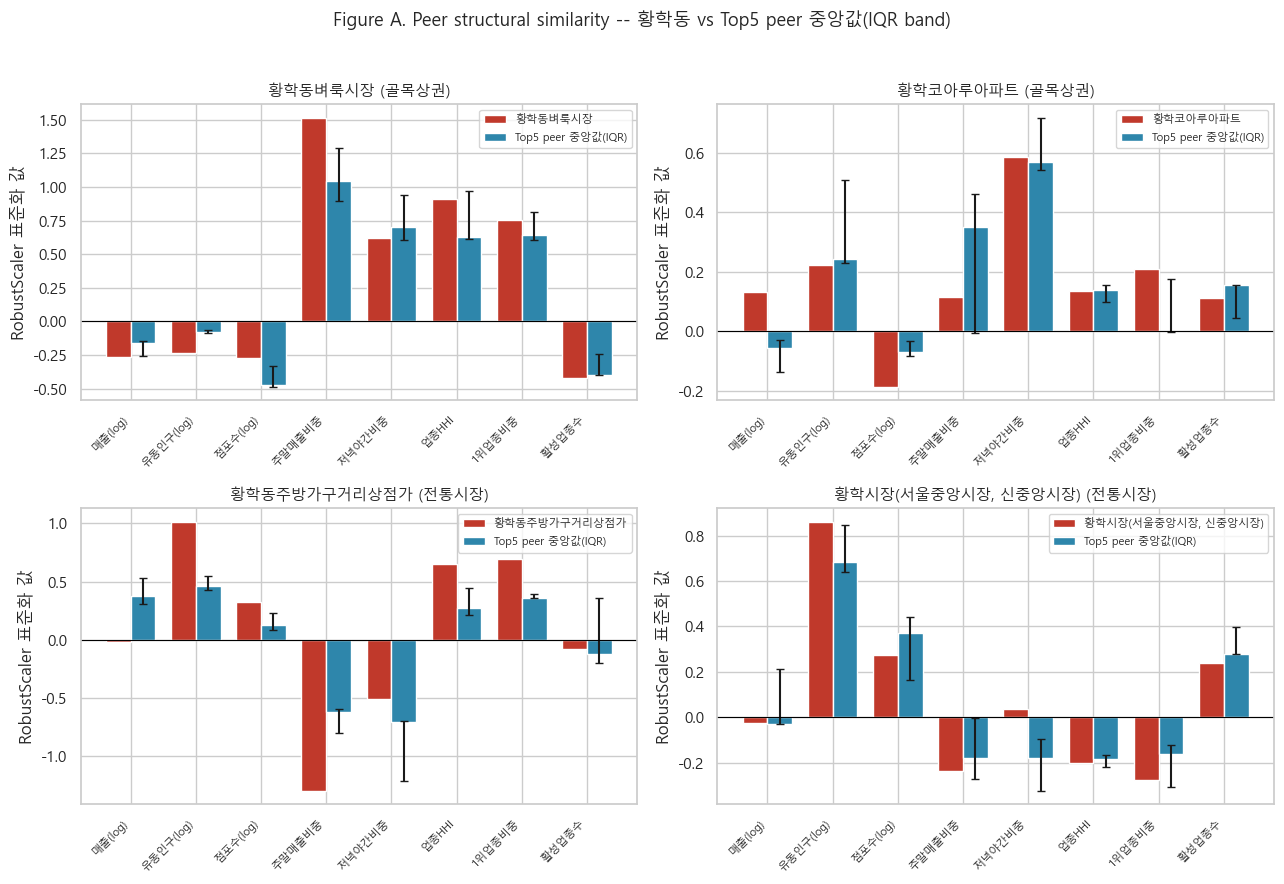

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

FEATURE_LABELS_KR = {
    "log_sales_4q_mean": "매출(log)",
    "log_population_4q_mean": "유동인구(log)",
    "log_store_4q_mean": "점포수(log)",
    "weekend_sales_share_4q_avg": "주말매출비중",
    "evening_night_sales_share_4q_avg": "저녁야간비중",
    "industry_hhi_4q_avg": "업종HHI",
    "top1_industry_share_4q_avg": "1위업종비중",
    "active_industry_count_4q_avg": "활성업종수",
}

for ax, code_ in zip(axes, HWANGHAK_CODES):
    area_type = HWANGHAK_TYPE_MAP[code_]
    pool = REFERENCE_POOLS[area_type]
    X_ref_scaled = TYPE_REF_SCALED[area_type]

    pool_code_to_pos = {v: i for i, v in enumerate(pool["상권_코드"].to_numpy())}
    top5_codes = matches[(matches["target_code"] == code_) & matches["is_top5"]]["peer_code"].tolist()
    top5_pos = [pool_code_to_pos[c] for c in top5_codes]

    peer5_scaled = X_ref_scaled[top5_pos]
    peer5_median = np.median(peer5_scaled, axis=0)
    peer5_p25 = np.percentile(peer5_scaled, 25, axis=0)
    peer5_p75 = np.percentile(peer5_scaled, 75, axis=0)
    yerr = np.vstack([peer5_median - peer5_p25, peer5_p75 - peer5_median])
    yerr[yerr < 0] = 0.0
    target_scaled = HWANGHAK_TARGET_SCALED[code_]

    x = np.arange(len(PEER_FEATURE_COLS))
    width = 0.38
    ax.bar(x - width / 2, target_scaled, width, label=HWANGHAK_NAME_MAP[code_], color=HWANGHAK_COLOR)
    ax.bar(x + width / 2, peer5_median, width, yerr=yerr, capsize=3,
           label=f"Top{TOP_DISPLAY_K} peer 중앙값(IQR)", color=PEER_COLOR)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([FEATURE_LABELS_KR[c] for c in PEER_FEATURE_COLS], rotation=45, ha="right", fontsize=8)
    ax.set_title(f"{HWANGHAK_NAME_MAP[code_]} ({area_type})", fontsize=11)
    ax.set_ylabel("RobustScaler 표준화 값")
    ax.legend(fontsize=8)

fig.suptitle("Figure A. Peer structural similarity -- 황학동 vs Top5 peer 중앙값(IQR band)", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 14. Peer 자체의 근접도 검증 (NN distance percentile)

Top1 peer의 distance 절대값만으로는 그 peer가 실제로 "가까운 편"인지 판단하기 어렵다. 이를 보완하기 위해, 각
상권유형 reference pool 내부에서 **자기 자신을 제외한 최근접 상권까지의 거리(leave-one-out NN distance)** 분포를
만들고, 황학동 각 상권의 Top1 peer distance가 그 분포에서 몇 percentile인지 계산한다.

- **percentile이 낮음** -> 같은 유형 내에서 그 정도로 가까운 상권 쌍이 흔함(황학동의 Top1 peer가 비교적 가까운 편)
- **percentile이 높음** -> 같은 유형 내에서 그만큼 가까운 상권 쌍이 드묾, 즉 **구조적으로 매우 가까운 비교
  대상이 상대적으로 적다**

percentile이 높다는 사실만으로 "고유한 상권"이라고 단정하지 않는다. 어디까지나 "그 정도로 가까운 비교 대상
자체가 상대적으로 드물다"는 의미로 제한해서 해석한다.

In [15]:
def percentile_of_score(distribution, value):
    distribution = np.asarray(distribution, dtype=float)
    distribution = distribution[~np.isnan(distribution)]
    if len(distribution) == 0 or pd.isna(value):
        return np.nan
    return float((distribution < value).mean() * 100)


TYPE_NN_DISTANCE_DIST = {}
for area_type, pool in REFERENCE_POOLS.items():
    X_ref_scaled = TYPE_REF_SCALED[area_type]
    nn_self = NearestNeighbors(n_neighbors=2, metric="euclidean")
    nn_self.fit(X_ref_scaled)
    self_distances, _ = nn_self.kneighbors(X_ref_scaled)
    TYPE_NN_DISTANCE_DIST[area_type] = self_distances[:, 1]  # 1열 = 자기 자신을 제외한 최근접 거리
    print(f"[{area_type}] reference 내부 최근접 거리 분포: n={len(pool)}, "
          f"median={np.median(TYPE_NN_DISTANCE_DIST[area_type]):.3f}")

nn_quality_records = []
for code_ in HWANGHAK_CODES:
    area_type = HWANGHAK_TYPE_MAP[code_]
    top1 = matches[(matches["target_code"] == code_) & (matches["peer_rank"] == 1)].iloc[0]
    dist_pct = percentile_of_score(TYPE_NN_DISTANCE_DIST[area_type], top1["distance"])
    nn_quality_records.append({
        "target_area": HWANGHAK_NAME_MAP[code_],
        "target_type": area_type,
        "top1_peer_area": top1["peer_area"],
        "nearest_peer_distance": top1["distance"],
        "nearest_peer_distance_percentile": dist_pct,
    })

nn_quality_df = pd.DataFrame(nn_quality_records)
print("\n=== 황학동 Top1 peer 근접도 ===")
print(nn_quality_df.round(3).to_string(index=False))

[골목상권] reference 내부 최근접 거리 분포: n=1022, median=0.560
[전통시장] reference 내부 최근접 거리 분포: n=276, median=0.703

=== 황학동 Top1 peer 근접도 ===
        target_area target_type   top1_peer_area  nearest_peer_distance  nearest_peer_distance_percentile
            황학동벼룩시장        골목상권 대림차이나타운(대림역 12번)                  0.489                            39.335
           황학코아루아파트        골목상권           행당역 2번                  0.373                            15.949
       황학동주방가구거리상점가        전통시장          영등포전통시장                  1.215                            90.942
황학시장(서울중앙시장, 신중앙시장)        전통시장             대조시장                  0.486                            27.174


## 15. Peer benchmark 및 서울 동일유형 benchmark 생성

각 황학동 상권에 대해 두 가지 benchmark를 만든다.

- **Benchmark A (Nearest Neighbor peer)**: Top 10 peer의 median/IQR. 통계는 Top 10, 대표 peer 이름은 Top 3만 표시.
- **Benchmark B (서울 동일 상권유형 전체)**: 같은 `상권_구분_코드_명`에 속하는 서울 전체 상권(황학동 제외)의 median.

비교 대상 metric은 05의 outcome signal, raw YoY, 04의 구조/업종 feature, 그리고 해석용 domain feature다. metric마다
peer 중 실제 결측이 아닌 표본 수(`{metric}_peer_n`)를 별도로 저장해 `peer_stats_n`(Top10으로 선택된 peer의 전체
개수)과 구분한다 -- 특정 peer가 그 metric에서 결측이면 `{metric}_peer_n < peer_stats_n`이 될 수 있다. 14절에서
계산한 `nearest_peer_distance`/`nearest_peer_distance_percentile`도 함께 저장한다.

In [16]:
SIGNAL_METRICS = [
    "direction_score", "structural_change_score", "decoupling_score",
    "instability_score", "change_intensity_score", "anomaly_percentile",
]
RAW_YOY_METRICS = ["sales_yoy", "transactions_yoy", "stores_yoy", "population_yoy"]
STRUCTURE_METRICS = [
    "weekend_sales_share", "evening_night_sales_share",
    "industry_hhi", "top1_industry_share", "active_industry_count",
]
DOMAIN_METRICS = ["furniture_sales_share", "korean_food_sales_share", "ecommerce_sales_share"]

DIAGNOSIS_METRICS = SIGNAL_METRICS + RAW_YOY_METRICS
DESCRIPTIVE_METRICS = STRUCTURE_METRICS + DOMAIN_METRICS
ALL_METRICS = DIAGNOSIS_METRICS + DESCRIPTIVE_METRICS

signals_latest = signals[signals["기준_년분기_코드"] == LATEST_QUARTER].copy()
features_latest = features[features["기준_년분기_코드"] == LATEST_QUARTER].copy()

combined_latest = signals_latest[
    ["상권_코드", "상권_코드_명", "상권_구분_코드_명", "signal_eligible"] + SIGNAL_METRICS + RAW_YOY_METRICS
].merge(
    features_latest[["상권_코드", "complete_case"] + STRUCTURE_METRICS + DOMAIN_METRICS],
    on="상권_코드", how="left",
)

assert not combined_latest.duplicated(subset=["상권_코드"]).any()
print("combined_latest shape:", combined_latest.shape)
combined_latest.head(3)

combined_latest shape: (1650, 23)


,상권_코드,상권_코드_명,상권_구분_코드_명,signal_eligible,direction_score,structural_change_score,decoupling_score,instability_score,change_intensity_score,anomaly_percentile,sales_yoy,transactions_yoy,stores_yoy,population_yoy,complete_case,weekend_sales_share,evening_night_sales_share,industry_hhi,top1_industry_share,active_industry_count,furniture_sales_share,korean_food_sales_share,ecommerce_sales_share
0,3001491,이태원 관광특구,관광특구,True,0.131042,30.878768,47.625015,50.466589,42.990124,0.578778,-2.678650,-4.277760,-1.292597,0.839817,True,0.438957,0.425910,0.132847,0.204879,33.0,0.000497,0.162148,0.000528
1,3001492,명동 남대문 북창동 다동 무교동 관광특구,관광특구,True,0.274545,32.225786,36.659000,41.148796,36.677860,3.858521,8.186477,2.656795,-1.296123,-3.873169,True,0.196415,0.311620,0.093239,0.228950,53.0,0.000824,0.228950,0.000070
2,3001493,동대문패션타운 관광특구,관광특구,True,0.102435,67.838358,87.736610,45.413364,66.996111,74.405145,19.723463,25.116447,-7.426471,-6.812660,True,0.258869,0.369738,0.336072,0.556948,39.0,0.007209,0.080346,0.000027


In [17]:
def summarize_stats(values):
    values = pd.Series(values, dtype=float).dropna()
    if len(values) == 0:
        return dict(median=np.nan, p25=np.nan, p75=np.nan, n=0)
    return dict(median=float(values.median()), p25=float(values.quantile(0.25)),
                p75=float(values.quantile(0.75)), n=int(len(values)))


def flag_from_stats(target_value, stats):
    if pd.isna(target_value) or stats["n"] == 0 or pd.isna(stats["p25"]) or pd.isna(stats["p75"]):
        return "NA"
    if target_value > stats["p75"]:
        return "HIGH"
    if target_value < stats["p25"]:
        return "LOW"
    return "TYPICAL"


combined_lookup = combined_latest.set_index("상권_코드")
nn_quality_lookup = nn_quality_df.set_index("target_area")

benchmark_records = []
for code_ in HWANGHAK_CODES:
    area_type = HWANGHAK_TYPE_MAP[code_]
    target_row = combined_lookup.loc[code_]
    target_area = HWANGHAK_NAME_MAP[code_]

    target_matches = matches[(matches["target_code"] == code_) & matches["is_top10"]].sort_values("peer_rank")
    peer10_codes = target_matches["peer_code"].tolist()
    top3_names = target_matches["peer_area"].tolist()[:3]
    top3_codes = target_matches["peer_code"].tolist()[:3]

    peer10_df = combined_lookup.loc[combined_lookup.index.intersection(peer10_codes)]

    seoul_type_df = combined_latest[
        (combined_latest["상권_구분_코드_명"] == area_type)
        & (~combined_latest["상권_코드"].isin(HWANGHAK_CODES))
    ]

    record = {
        "target_area": target_area,
        "target_code": code_,
        "target_type": area_type,
        "peer_pool_size": len(REFERENCE_POOLS[area_type]),
        "peer_stats_n": len(peer10_df),
        "nearest_peer_distance": nn_quality_lookup.loc[target_area, "nearest_peer_distance"],
        "nearest_peer_distance_percentile": nn_quality_lookup.loc[target_area, "nearest_peer_distance_percentile"],
    }
    for i in range(3):
        record[f"representative_peer_{i + 1}"] = top3_names[i] if i < len(top3_names) else np.nan
        record[f"representative_peer_{i + 1}_code"] = top3_codes[i] if i < len(top3_codes) else np.nan

    for metric in ALL_METRICS:
        target_value = target_row[metric]
        peer_values = peer10_df[metric] if metric in peer10_df.columns else pd.Series(dtype=float)
        seoul_values = seoul_type_df[metric] if metric in seoul_type_df.columns else pd.Series(dtype=float)

        peer_stats = summarize_stats(peer_values)
        seoul_median = float(seoul_values.dropna().median()) if seoul_values.notna().any() else np.nan

        record[metric] = target_value
        record[f"{metric}_peer_n"] = peer_stats["n"]
        record[f"{metric}_peer_median"] = peer_stats["median"]
        record[f"{metric}_peer_gap"] = (
            target_value - peer_stats["median"] if pd.notna(target_value) and pd.notna(peer_stats["median"]) else np.nan
        )
        record[f"{metric}_seoul_type_median"] = seoul_median
        record[f"{metric}_seoul_type_gap"] = (
            target_value - seoul_median if pd.notna(target_value) and pd.notna(seoul_median) else np.nan
        )
        if metric in DIAGNOSIS_METRICS:
            record[f"{metric}_peer_flag"] = flag_from_stats(target_value, peer_stats)

    benchmark_records.append(record)

peer_benchmark_df = pd.DataFrame(benchmark_records)
print("peer_benchmark_df shape:", peer_benchmark_df.shape)

low_n_report = []
for metric in ALL_METRICS:
    col = f"{metric}_peer_n"
    low = peer_benchmark_df[peer_benchmark_df[col] < TOP_STATS_K][["target_area", col]]
    for _, r in low.iterrows():
        low_n_report.append((r["target_area"], metric, int(r[col])))

if low_n_report:
    print(f"\nTop{TOP_STATS_K} 중 일부 peer가 해당 metric에서 결측이라 유효 표본이 {TOP_STATS_K} 미만인 경우:")
    for t, m, n in low_n_report:
        print(f"  - {t} / {m}: peer_n={n}")
else:
    print(f"\n모든 target x metric 조합에서 peer_n == TOP_STATS_K({TOP_STATS_K}) 입니다.")

peer_benchmark_df[["target_area", "representative_peer_1", "representative_peer_2", "representative_peer_3"]]

peer_benchmark_df shape: (4, 131)

모든 target x metric 조합에서 peer_n == TOP_STATS_K(10) 입니다.


,target_area,representative_peer_1,representative_peer_2,representative_peer_3
0,황학동벼룩시장,대림차이나타운(대림역 12번),망원나들목체육관,도봉구민회관
1,황학코아루아파트,행당역 2번,경의중앙 신촌역,새터산
2,황학동주방가구거리상점가,영등포전통시장,통인시장,청량종합도매시장
3,"황학시장(서울중앙시장, 신중앙시장)",대조시장,동화동 골목형상점가,상계중앙시장


## 16. Signal 비교 시각화 (Figure B)

`direction_score`(-1~1)는 나머지 signal(0~100)과 척도가 다르므로 별도 그래프로 분리한다.

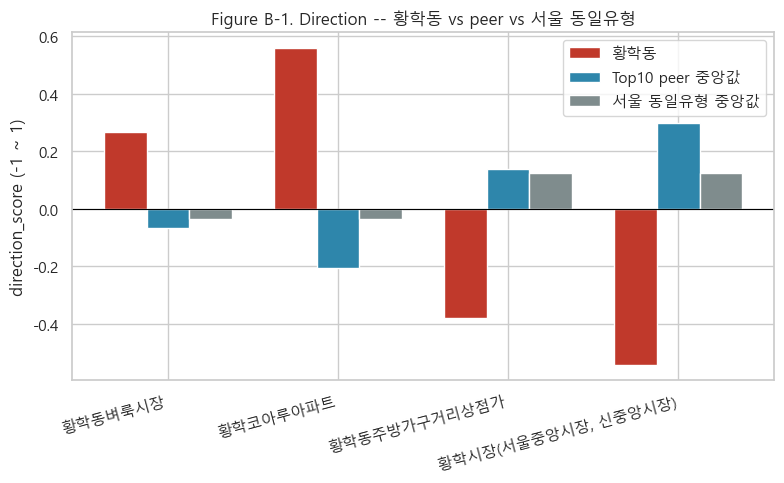

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(HWANGHAK_CODES))
width = 0.25

bidx = peer_benchmark_df.set_index("target_code")
target_vals = bidx.loc[HWANGHAK_CODES, "direction_score"].to_numpy()
peer_vals = bidx.loc[HWANGHAK_CODES, "direction_score_peer_median"].to_numpy()
seoul_vals = bidx.loc[HWANGHAK_CODES, "direction_score_seoul_type_median"].to_numpy()
labels = [HWANGHAK_NAME_MAP[c] for c in HWANGHAK_CODES]

ax.bar(x - width, target_vals, width, label="황학동", color=HWANGHAK_COLOR)
ax.bar(x, peer_vals, width, label=f"Top{TOP_STATS_K} peer 중앙값", color=PEER_COLOR)
ax.bar(x + width, seoul_vals, width, label="서울 동일유형 중앙값", color=SEOUL_TYPE_COLOR)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha="right")
ax.set_ylabel("direction_score (-1 ~ 1)")
ax.set_title("Figure B-1. Direction -- 황학동 vs peer vs 서울 동일유형")
ax.legend()
plt.tight_layout()
plt.show()

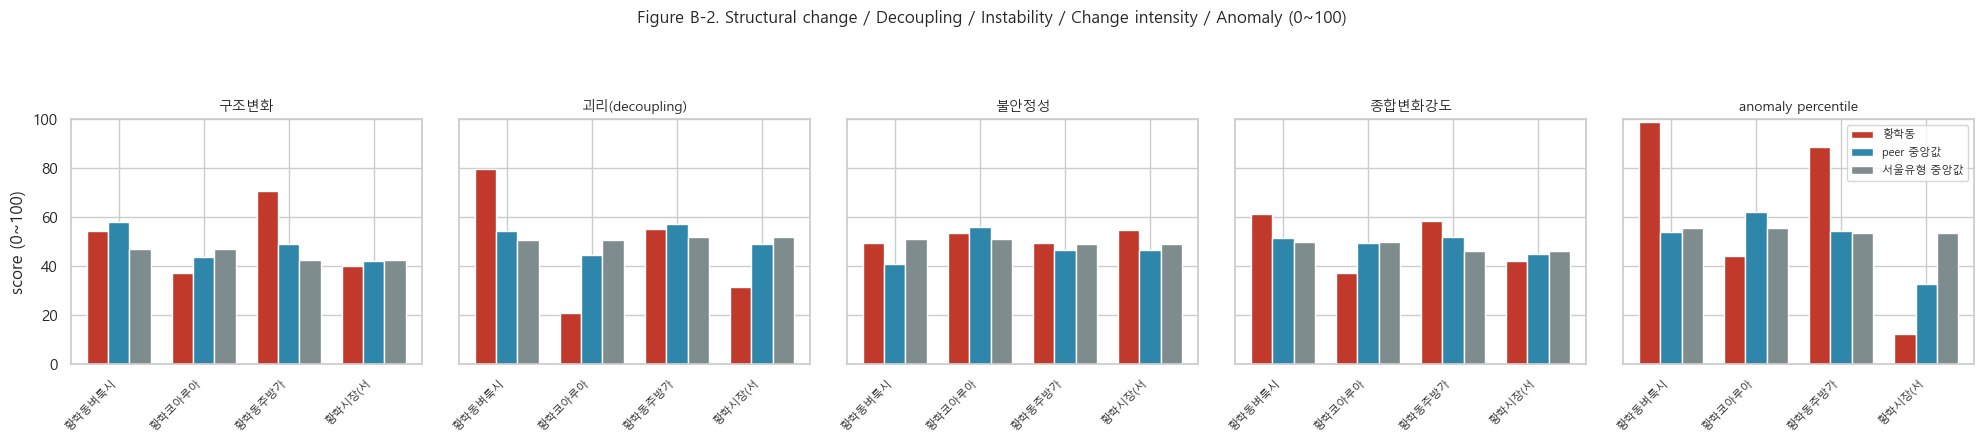

In [19]:
OTHER_SIGNALS = [m for m in SIGNAL_METRICS if m != "direction_score"]
SIGNAL_LABELS_KR = {
    "structural_change_score": "구조변화",
    "decoupling_score": "괴리(decoupling)",
    "instability_score": "불안정성",
    "change_intensity_score": "종합변화강도",
    "anomaly_percentile": "anomaly percentile",
}

fig, axes = plt.subplots(1, len(OTHER_SIGNALS), figsize=(4 * len(OTHER_SIGNALS), 4.5), sharey=True)
x = np.arange(len(HWANGHAK_CODES))
width = 0.25
bidx = peer_benchmark_df.set_index("target_code")

for ax, metric in zip(axes, OTHER_SIGNALS):
    target_vals = bidx.loc[HWANGHAK_CODES, metric].to_numpy()
    peer_vals = bidx.loc[HWANGHAK_CODES, f"{metric}_peer_median"].to_numpy()
    seoul_vals = bidx.loc[HWANGHAK_CODES, f"{metric}_seoul_type_median"].to_numpy()

    ax.bar(x - width, target_vals, width, label="황학동", color=HWANGHAK_COLOR)
    ax.bar(x, peer_vals, width, label="peer 중앙값", color=PEER_COLOR)
    ax.bar(x + width, seoul_vals, width, label="서울유형 중앙값", color=SEOUL_TYPE_COLOR)
    ax.set_xticks(x)
    ax.set_xticklabels([HWANGHAK_NAME_MAP[c][:6] for c in HWANGHAK_CODES], rotation=45, ha="right", fontsize=8)
    ax.set_title(SIGNAL_LABELS_KR[metric], fontsize=10)
    ax.set_ylim(0, 100)

axes[0].set_ylabel("score (0~100)")
axes[-1].legend(fontsize=8, loc="upper right")
fig.suptitle("Figure B-2. Structural change / Decoupling / Instability / Change intensity / Anomaly (0~100)", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

## 17. Raw YoY 비교 시각화 (Figure C)

signal은 서울 내 상대적 위치(percentile 기반)라 실제 증감 방향/크기를 직접 보여주지 않는다. raw YoY(%)를 함께
비교해 실제 매출/거래/점포/유동인구가 얼마나 늘거나 줄었는지 확인한다.

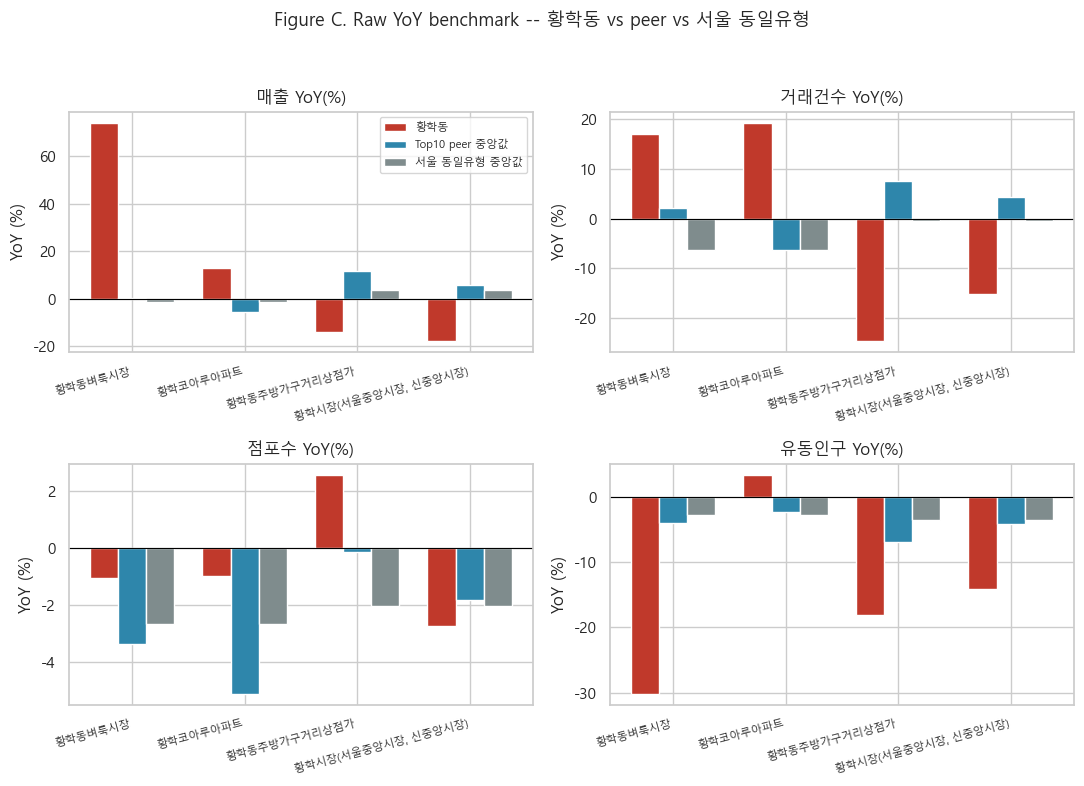

In [20]:
RAW_YOY_LABELS_KR = {
    "sales_yoy": "매출 YoY(%)", "transactions_yoy": "거래건수 YoY(%)",
    "stores_yoy": "점포수 YoY(%)", "population_yoy": "유동인구 YoY(%)",
}

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.flatten()
x = np.arange(len(HWANGHAK_CODES))
width = 0.25
bidx = peer_benchmark_df.set_index("target_code")

for ax, metric in zip(axes, RAW_YOY_METRICS):
    target_vals = bidx.loc[HWANGHAK_CODES, metric].to_numpy()
    peer_vals = bidx.loc[HWANGHAK_CODES, f"{metric}_peer_median"].to_numpy()
    seoul_vals = bidx.loc[HWANGHAK_CODES, f"{metric}_seoul_type_median"].to_numpy()

    ax.bar(x - width, target_vals, width, label="황학동", color=HWANGHAK_COLOR)
    ax.bar(x, peer_vals, width, label=f"Top{TOP_STATS_K} peer 중앙값", color=PEER_COLOR)
    ax.bar(x + width, seoul_vals, width, label="서울 동일유형 중앙값", color=SEOUL_TYPE_COLOR)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([HWANGHAK_NAME_MAP[c] for c in HWANGHAK_CODES], rotation=15, ha="right", fontsize=8)
    ax.set_title(RAW_YOY_LABELS_KR[metric])
    ax.set_ylabel("YoY (%)")

axes[0].legend(fontsize=8)
fig.suptitle("Figure C. Raw YoY benchmark -- 황학동 vs peer vs 서울 동일유형", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 18. 구조 및 domain feature 비교

peer selection에 사용한 구조 feature(원 단위)와, selection에는 쓰지 않았지만 03 EDA에서 확인된 domain feature를
함께 표로 확인한다.

In [21]:
def build_metric_table(metrics, title):
    rows = []
    for code_ in HWANGHAK_CODES:
        rec = peer_benchmark_df[peer_benchmark_df["target_code"] == code_].iloc[0]
        for metric in metrics:
            rows.append({
                "target_area": HWANGHAK_NAME_MAP[code_],
                "metric": metric,
                "target_value": rec[metric],
                "peer_median": rec[f"{metric}_peer_median"],
                "seoul_type_median": rec[f"{metric}_seoul_type_median"],
                "peer_gap": rec[f"{metric}_peer_gap"],
            })
    table = pd.DataFrame(rows)
    print(f"=== {title} ===")
    print(table.round(4).to_string(index=False))
    return table


structure_table = build_metric_table(STRUCTURE_METRICS, "구조 feature 비교(target vs peer vs 서울유형)")
print()
domain_table = build_metric_table(DOMAIN_METRICS, "domain-informed feature 비교(해석 전용, peer selection에는 미사용)")

=== 구조 feature 비교(target vs peer vs 서울유형) ===
        target_area                    metric  target_value  peer_median  seoul_type_median  peer_gap
            황학동벼룩시장       weekend_sales_share        0.8180       0.3417             0.2479    0.4763
            황학동벼룩시장 evening_night_sales_share        0.0726       0.5279             0.4070   -0.4553
            황학동벼룩시장              industry_hhi        0.6541       0.5777             0.3278    0.0764
            황학동벼룩시장       top1_industry_share        0.7979       0.7470             0.4794    0.0509
            황학동벼룩시장     active_industry_count        4.0000       5.0000             8.0000   -1.0000
           황학코아루아파트       weekend_sales_share        0.2886       0.2745             0.2479    0.0141
           황학코아루아파트 evening_night_sales_share        0.5486       0.5064             0.4070    0.0422
           황학코아루아파트              industry_hhi        0.4005       0.3397             0.3278    0.0608
           황학코아루아파트       top1_indus

## 19. 황학동별 peer-relative 진단 (rule-based)

가치판단("좋다/나쁘다")이 아니라 **상대 비교 표현**(높음/낮음/유사)만 사용한다. `HIGH`/`TYPICAL`/`LOW`는 Top 10
peer 분포의 25~75 percentile(IQR) 기준이다. `anomaly_percentile`이 `HIGH`인 경우에만 "이례적"이라는 표현을
추가한다(anomaly의 정의상 실제로 이례적이라는 뜻이기 때문).

In [22]:
METRIC_LABELS_KR = {
    "direction_score": "방향성(direction)",
    "structural_change_score": "구조 변화 강도",
    "decoupling_score": "매출-유동/점포 괴리(decoupling)",
    "instability_score": "변동성/불안정성(instability)",
    "change_intensity_score": "종합 변화 강도",
    "anomaly_percentile": "이상성(anomaly)",
    "sales_yoy": "매출 YoY", "transactions_yoy": "거래건수 YoY",
    "stores_yoy": "점포수 YoY", "population_yoy": "유동인구 YoY",
}


def describe_flag(metric, flag):
    base = {"HIGH": "높음", "LOW": "낮음", "TYPICAL": "유사", "NA": "판단 불가(자료 부족)"}[flag]
    if metric == "anomaly_percentile" and flag == "HIGH":
        return "매우 높음(이례적)"
    return base


for code_ in HWANGHAK_CODES:
    rec = peer_benchmark_df[peer_benchmark_df["target_code"] == code_].iloc[0]
    print(f"\n[{HWANGHAK_NAME_MAP[code_]}] (Top{TOP_STATS_K} peer 대비, {rec['target_type']} 유형)")
    for metric in DIAGNOSIS_METRICS:
        flag = rec[f"{metric}_peer_flag"]
        gap = rec[f"{metric}_peer_gap"]
        gap_str = f"{gap:+.2f}" if pd.notna(gap) else "NA"
        print(f"  - Peer 대비 {METRIC_LABELS_KR[metric]}: {describe_flag(metric, flag)} (gap={gap_str})")


[황학동벼룩시장] (Top10 peer 대비, 골목상권 유형)
  - Peer 대비 방향성(direction): 유사 (gap=+0.33)
  - Peer 대비 구조 변화 강도: 유사 (gap=-3.49)
  - Peer 대비 매출-유동/점포 괴리(decoupling): 높음 (gap=+25.20)
  - Peer 대비 변동성/불안정성(instability): 유사 (gap=+8.56)
  - Peer 대비 종합 변화 강도: 높음 (gap=+9.61)
  - Peer 대비 이상성(anomaly): 매우 높음(이례적) (gap=+45.05)
  - Peer 대비 매출 YoY: 높음 (gap=+74.23)
  - Peer 대비 거래건수 YoY: 유사 (gap=+14.93)
  - Peer 대비 점포수 YoY: 높음 (gap=+2.34)
  - Peer 대비 유동인구 YoY: 낮음 (gap=-26.20)

[황학코아루아파트] (Top10 peer 대비, 골목상권 유형)
  - Peer 대비 방향성(direction): 높음 (gap=+0.77)
  - Peer 대비 구조 변화 강도: 낮음 (gap=-6.68)
  - Peer 대비 매출-유동/점포 괴리(decoupling): 낮음 (gap=-23.67)
  - Peer 대비 변동성/불안정성(instability): 유사 (gap=-2.26)
  - Peer 대비 종합 변화 강도: 낮음 (gap=-12.05)
  - Peer 대비 이상성(anomaly): 유사 (gap=-17.78)
  - Peer 대비 매출 YoY: 높음 (gap=+18.63)
  - Peer 대비 거래건수 YoY: 높음 (gap=+25.65)
  - Peer 대비 점포수 YoY: 높음 (gap=+4.15)
  - Peer 대비 유동인구 YoY: 높음 (gap=+5.70)

[황학동주방가구거리상점가] (Top10 peer 대비, 전통시장 유형)
  - Peer 대비 방향성(direction): 낮음 (gap=-0.52)
  - Peer 대비 구조 

## 20. K sensitivity (Top5 / Top10 / Top20)

Top 5 median과 Top 10 median의 부호(방향) 일치율만 보던 이전 점검을 Top 20까지 확장한다. gap이 0에 매우 가까운
경우 표본이 조금만 달라져도 부호가 뒤집힐 수 있으므로, metric의 척도에 맞춘 **tolerance**를 두고 그 이내의 gap은
"방향 불문(사실상 유사)"으로 처리한다.

- `direction_score`(-1~1 척도): tolerance = 0.02
- 나머지 signal(0~100 척도: structural_change/decoupling/instability/change_intensity/anomaly_percentile):
  tolerance = 2.0(포인트)
- raw YoY(%): tolerance = 1.0(%p)

tolerance는 각 척도에서 "사실상 차이가 없다"고 볼 수 있는 작은 폭(척도 범위의 1~2% 내외)으로 설정했다. 이 값
자체가 절대적 기준은 아니며, gap의 부호가 tolerance 근처에서 흔들리는 경우를 걸러내기 위한 최소한의 장치다.

In [23]:
K_LEVELS = [5, 10, 20]
DIRECTION_TOLERANCE = {"direction_score": 0.02}
DEFAULT_SCORE_TOLERANCE = 2.0
DEFAULT_YOY_TOLERANCE = 1.0


def metric_tolerance(metric):
    if metric in DIRECTION_TOLERANCE:
        return DIRECTION_TOLERANCE[metric]
    if metric in RAW_YOY_METRICS:
        return DEFAULT_YOY_TOLERANCE
    return DEFAULT_SCORE_TOLERANCE


def signed_direction(gap, tol):
    if pd.isna(gap):
        return np.nan
    if abs(gap) <= tol:
        return 0.0
    return 1.0 if gap > 0 else -1.0


k_sensitivity_records = []
for code_ in HWANGHAK_CODES:
    for metric in DIAGNOSIS_METRICS:
        target_value = combined_lookup.loc[code_, metric]
        tol = metric_tolerance(metric)
        row = {
            "target_area": HWANGHAK_NAME_MAP[code_], "target_code": code_,
            "metric": metric, "tolerance": tol,
        }
        gaps = {}
        for K in K_LEVELS:
            topk_codes = matches[(matches["target_code"] == code_) & (matches["peer_rank"] <= K)]["peer_code"].tolist()
            peerk_df = combined_lookup.loc[combined_lookup.index.intersection(topk_codes)]
            peerk_median = peerk_df[metric].median()
            gap = target_value - peerk_median if pd.notna(target_value) and pd.notna(peerk_median) else np.nan
            row[f"peer_median_top{K}"] = peerk_median
            row[f"gap_top{K}"] = gap
            gaps[K] = gap

        row["direction_top5"] = signed_direction(gaps[5], tol)
        row["direction_top10"] = signed_direction(gaps[10], tol)
        row["direction_top20"] = signed_direction(gaps[20], tol)
        d5, d10, d20 = row["direction_top5"], row["direction_top10"], row["direction_top20"]
        row["top5_vs_top10_same"] = (d5 == d10) if pd.notna(d5) and pd.notna(d10) else np.nan
        row["top10_vs_top20_same"] = (d10 == d20) if pd.notna(d10) and pd.notna(d20) else np.nan
        row["top5_vs_top20_same"] = (d5 == d20) if pd.notna(d5) and pd.notna(d20) else np.nan
        if pd.notna(row["top5_vs_top10_same"]) and pd.notna(row["top10_vs_top20_same"]):
            row["all_three_same"] = bool(row["top5_vs_top10_same"] and row["top10_vs_top20_same"])
        else:
            row["all_three_same"] = np.nan

        k_sensitivity_records.append(row)

k_sensitivity_df = pd.DataFrame(k_sensitivity_records)


def _rate(col):
    valid = k_sensitivity_df[col].dropna()
    return float(valid.mean() * 100) if len(valid) > 0 else np.nan


rate_5_10 = _rate("top5_vs_top10_same")
rate_10_20 = _rate("top10_vs_top20_same")
rate_5_20 = _rate("top5_vs_top20_same")
rate_all3 = _rate("all_three_same")

print(f"Top5 vs Top10 방향 일치율: {rate_5_10:.1f}%")
print(f"Top10 vs Top20 방향 일치율: {rate_10_20:.1f}%")
print(f"Top5 vs Top20 방향 일치율: {rate_5_20:.1f}%")
print(f"세 K(5/10/20) 모두 동일 방향인 비율: {rate_all3:.1f}%")

unstable = k_sensitivity_df[k_sensitivity_df["all_three_same"] == False]
print(f"\nK에 따라 방향이 달라지는 (target, metric) 조합 ({len(unstable)}건):")
print(unstable[["target_area", "metric", "gap_top5", "gap_top10", "gap_top20"]].round(3).to_string(index=False)
      if len(unstable) > 0 else "없음")

# metric별로 4개 target 전체에서 세 K가 모두 동일 방향이었던 비율을 요약한다(추가 모델 없이 기존 결과 재집계).
metric_stability = (
    k_sensitivity_df.groupby("metric")["all_three_same"]
    .apply(lambda s: float(s.dropna().mean() * 100) if s.notna().any() else np.nan)
    .rename("all_three_same_rate_pct")
    .reset_index()
    .sort_values("all_three_same_rate_pct")
)
STABLE_METRICS = set(metric_stability.loc[metric_stability["all_three_same_rate_pct"] >= 75, "metric"])
UNSTABLE_METRICS = set(metric_stability.loc[metric_stability["all_three_same_rate_pct"] < 75, "metric"])

print("\nmetric별 K(5/10/20) 방향 일치율(4개 target 기준, all_three_same 비율, %):")
print(metric_stability.round(1).to_string(index=False))
print("\nK 선택에 상대적으로 민감한(4개 target 중 75% 미만에서 일치) metric:",
      sorted(UNSTABLE_METRICS) if UNSTABLE_METRICS else "없음")
print("이 metric들은 K sensitivity가 낮으므로 최종 진단에서 주된 근거로 강하게 사용하지 않고 보조적으로만 참고한다.")

Top5 vs Top10 방향 일치율: 87.5%
Top10 vs Top20 방향 일치율: 90.0%
Top5 vs Top20 방향 일치율: 87.5%
세 K(5/10/20) 모두 동일 방향인 비율: 82.5%

K에 따라 방향이 달라지는 (target, metric) 조합 (7건):
        target_area                  metric  gap_top5  gap_top10  gap_top20
            황학동벼룩시장 structural_change_score    -6.248     -3.489      2.733
            황학동벼룩시장       instability_score    32.882      8.563     -1.572
           황학코아루아파트       instability_score    -1.683     -2.256     -4.964
       황학동주방가구거리상점가       instability_score     1.276      2.543      2.543
황학시장(서울중앙시장, 신중앙시장) structural_change_score     0.757     -2.014      1.328
황학시장(서울중앙시장, 신중앙시장)       instability_score    -0.424      8.117      8.117
황학시장(서울중앙시장, 신중앙시장)              stores_yoy    -1.839     -0.904     -1.327

metric별 K(5/10/20) 방향 일치율(4개 target 기준, all_three_same 비율, %):
                 metric  all_three_same_rate_pct
      instability_score                      0.0
structural_change_score                     50.0
             stores_y

## 21. Feature sensitivity (HHI vs Top1 비중 중복 여부, Jaccard similarity)

기본 8개 `PEER_FEATURE_COLS`는 그대로 유지한다. 다만 `industry_hhi_4q_avg`와 `top1_industry_share_4q_avg`가
업종 집중도를 일부 중복해서 설명할 가능성이 있으므로, 다음 3가지 feature set으로 Top 10 peer 집합을 각각 다시
구해 **Jaccard similarity**(교집합/합집합)로 얼마나 달라지는지 확인한다.

- **Set A**: 기본 8개 feature(현재 모델)
- **Set B**: `industry_hhi_4q_avg` 제외
- **Set C**: `top1_industry_share_4q_avg` 제외

목적은 두 변수의 중복 여부를 확인하는 것이지, 기본 feature set을 바꾸기 위한 것이 아니다.

In [24]:
FEATURE_SET_A = list(PEER_FEATURE_COLS)
FEATURE_SET_B = [c for c in PEER_FEATURE_COLS if c != "industry_hhi_4q_avg"]
FEATURE_SET_C = [c for c in PEER_FEATURE_COLS if c != "top1_industry_share_4q_avg"]
FEATURE_SETS = {"B(HHI 제외)": FEATURE_SET_B, "C(top1비중 제외)": FEATURE_SET_C}


def top10_peer_codes_for_featureset(code_, cols):
    area_type = HWANGHAK_TYPE_MAP[code_]
    pool = REFERENCE_POOLS[area_type]
    scaler = RobustScaler()
    X_ref = scaler.fit_transform(pool[cols])
    target_row = baseline_latest[baseline_latest["상권_코드"] == code_][cols]
    X_target = scaler.transform(target_row)[0]
    k = min(TOP_STATS_K, len(pool))
    nn = NearestNeighbors(n_neighbors=k, metric="euclidean")
    nn.fit(X_ref)
    _, indices = nn.kneighbors(X_target.reshape(1, -1))
    return set(pool.iloc[indices[0]]["상권_코드"].astype(int).tolist())


def jaccard(set1, set2):
    union = set1 | set2
    if len(union) == 0:
        return np.nan
    return len(set1 & set2) / len(union)


base_top10_by_code = {code_: top10_peer_codes_for_featureset(code_, FEATURE_SET_A) for code_ in HWANGHAK_CODES}

jaccard_records = []
for code_ in HWANGHAK_CODES:
    base_set = base_top10_by_code[code_]
    for label, cols in FEATURE_SETS.items():
        alt_set = top10_peer_codes_for_featureset(code_, cols)
        jaccard_records.append({
            "target_area": HWANGHAK_NAME_MAP[code_],
            "feature_set": label,
            "n_overlap": len(base_set & alt_set),
            "n_union": len(base_set | alt_set),
            "jaccard_vs_A": jaccard(base_set, alt_set),
        })

jaccard_df = pd.DataFrame(jaccard_records)
print(jaccard_df.round(3).to_string(index=False))

mean_jaccard = float(jaccard_df["jaccard_vs_A"].mean())
print(f"\n평균 Jaccard similarity: {mean_jaccard:.3f}")

min_jaccard = float(jaccard_df["jaccard_vs_A"].min())
max_jaccard = float(jaccard_df["jaccard_vs_A"].max())

if mean_jaccard >= 0.6:
    print(f"\nHHI 또는 Top1 업종 비중을 제외하더라도 평균 Jaccard가 {mean_jaccard:.2f}(범위 {min_jaccard:.2f}~"
          f"{max_jaccard:.2f})로 Top10 peer의 상당수가 유지되어 기본 8개 feature 구성은 전반적으로 안정적이다."
          " 다만 일부 상권은 peer 일부가 교체되므로(완전히 동일하지는 않다), 개별 peer 자체보다 peer 집단"
          f"(Top{TOP_STATS_K})의 중앙값과 공통 방향을 중심으로 해석한다. 이러한 이유로 기본 8개 feature"
          " (Set A)를 그대로 유지한다.")
else:
    print(f"\n평균 Jaccard가 {mean_jaccard:.2f}(범위 {min_jaccard:.2f}~{max_jaccard:.2f})로 낮게 나타나,"
          " HHI/top1비중 제외 여부에 따라 peer 구성이 상당히 달라진다. 다만 이번 분석에서는 기본 8개"
          " feature(Set A)를 그대로 유지하되, 이 민감도를 한계로 기록해 둔다.")

        target_area  feature_set  n_overlap  n_union  jaccard_vs_A
            황학동벼룩시장    B(HHI 제외)          9       11         0.818
            황학동벼룩시장 C(top1비중 제외)          9       11         0.818
           황학코아루아파트    B(HHI 제외)          9       11         0.818
           황학코아루아파트 C(top1비중 제외)          8       12         0.667
       황학동주방가구거리상점가    B(HHI 제외)          9       11         0.818
       황학동주방가구거리상점가 C(top1비중 제외)          8       12         0.667
황학시장(서울중앙시장, 신중앙시장)    B(HHI 제외)         10       10         1.000
황학시장(서울중앙시장, 신중앙시장) C(top1비중 제외)         10       10         1.000

평균 Jaccard similarity: 0.826

HHI 또는 Top1 업종 비중을 제외하더라도 평균 Jaccard가 0.83(범위 0.67~1.00)로 Top10 peer의 상당수가 유지되어 기본 8개 feature 구성은 전반적으로 안정적이다. 다만 일부 상권은 peer 일부가 교체되므로(완전히 동일하지는 않다), 개별 peer 자체보다 peer 집단(Top10)의 중앙값과 공통 방향을 중심으로 해석한다. 이러한 이유로 기본 8개 feature (Set A)를 그대로 유지한다.


## 22. 결과 해석 시 주의사항

1. **Nearest Neighbor는 "성공한 상권"을 자동으로 찾는 모델이 아니다.** 구조(규모·업종·소비시간대)가 비슷한
   비교 대상을 찾을 뿐이며, peer가 실제로 잘 되고 있다는 보장은 없다.
2. **거리가 가깝다고 인과관계가 있는 것은 아니다.** 구조적 유사성과 변화 패턴의 유사성은 별개의 문제다.
3. **peer보다 매출/거래/유동인구가 높다고 해서 정책적으로 더 우수한 상권이라고 단정하지 않는다.** 통제되지
   않은 다른 요인(입지, 재건축/개발 이슈 등)이 있을 수 있다.
4. **`anomaly_percentile`은 위험 확률이 아니다.** 05에서 확인했듯 이상치는 급성장 등 다른 이유로도 발생할 수 있다.
5. **Peer comparison은 정책 전략 수립을 위한 benchmark이지 causal impact estimation이 아니다.** 이번 노트북은
   어떤 정책이 효과가 있을지 추정하지 않는다.
6. **"peer보다 높다/낮다"(상대 변화)와 "실제로 늘었다/줄었다"(절대 변화)를 구분한다.** 예를 들어 target YoY가
   -1%이고 peer median YoY가 -5%라면 `peer_gap`은 +4%p로 양수이지만, target 역시 실제로는 감소한 것이다. 아래 최종 해석에서는 이 둘을 분리해서 표현한다.
7. **peer는 "개별 상권"이 아니라 "peer 집단"으로 본다.** Top1 peer는 가장 가까운 참고 사례일 뿐이고, 이 노트북의
   실제 benchmark는 Top10 median이다. 특정 1개 peer의 특성을 황학동과 동일시하지 않는다.
8. **NN distance percentile이 높다고 "서울에서 유일한 상권"이라고 해석하지 않는다.** "같은 상권유형 내에서
   구조적으로 매우 가까운 비교 대상이 상대적으로 적다"는 정도로만 해석하며, NN percentile은 peer 품질(matching
   난이도)에 대한 보조 정보일 뿐 anomaly나 특이성 자체의 근거로 쓰지 않는다.

## 23. 결과 저장

`hwanghak_peer_matches.csv`(target x peer, rank 1~20, `is_top5`/`is_top10`/`is_top20` flag 포함)와
`hwanghak_peer_benchmark.csv`(target 4행, 각 metric의 target/peer_n/peer_median/peer_gap/peer_flag/
seoul_type_median/seoul_type_gap + nearest_peer_distance/percentile)를 저장한다. K sensitivity 결과는
`hwanghak_peer_robustness.csv`로 별도 저장한다(target x metric x K, 향후 재사용 가치가 있는 표 형태이므로).
Jaccard feature sensitivity 결과는 방법론 점검용 1회성 확인이라 별도 CSV로 저장하지 않는다. 컬럼이 많아지므로
해석을 돕는 `peer_benchmark_dictionary.csv`도 함께 저장한다.

In [25]:
MATCHES_COLUMN_ORDER = (
    ["target_area", "target_code", "target_type", "peer_rank", "peer_area", "peer_code", "distance",
     "is_top5", "is_top10", "is_top20"]
    + [f"target_{c}" for c in RAW_COMPARE_COLS]
    + [f"peer_{c}" for c in RAW_COMPARE_COLS]
)
hwanghak_peer_matches = matches[MATCHES_COLUMN_ORDER].copy()
print("hwanghak_peer_matches shape:", hwanghak_peer_matches.shape)
hwanghak_peer_matches.head(3)

hwanghak_peer_matches shape: (80, 26)


,target_area,target_code,target_type,peer_rank,peer_area,peer_code,distance,is_top5,is_top10,is_top20,target_sales_4q_mean_baseline,target_population_4q_mean_baseline,target_store_4q_mean_baseline,target_weekend_sales_share_4q_avg,target_evening_night_sales_share_4q_avg,target_industry_hhi_4q_avg,target_top1_industry_share_4q_avg,target_active_industry_count_4q_avg,peer_sales_4q_mean_baseline,peer_population_4q_mean_baseline,peer_store_4q_mean_baseline,peer_weekend_sales_share_4q_avg,peer_evening_night_sales_share_4q_avg,peer_industry_hhi_4q_avg,peer_top1_industry_share_4q_avg,peer_active_industry_count_4q_avg
0,황학동벼룩시장,3110055,골목상권,1,대림차이나타운(대림역 12번),3110769,0.489116,True,True,True,1.192033e+09,459629.25,93.25,0.396976,0.519541,0.61426,0.736219,3.75,1.217959e+09,572818.50,87.25,0.407349,0.572804,0.522700,0.698404,4.00
1,황학동벼룩시장,3110055,골목상권,2,망원나들목체육관,3110540,0.775006,True,True,True,1.192033e+09,459629.25,93.25,0.396976,0.519541,0.61426,0.736219,3.75,7.999748e+08,567114.75,75.00,0.350972,0.533764,0.492048,0.621788,3.50
2,황학동벼룩시장,3110055,골목상권,3,도봉구민회관,3110401,0.838997,True,True,True,1.192033e+09,459629.25,93.25,0.396976,0.519541,0.61426,0.736219,3.75,1.449060e+09,202437.75,54.75,0.374928,0.516992,0.633254,0.788397,5.75


In [26]:
metric_source = {}
for m in SIGNAL_METRICS + RAW_YOY_METRICS:
    metric_source[m] = "signal_dictionary.csv (05)" if m in signal_dictionary["signal"].values else "commercial_signals 원본 컬럼"
for m in STRUCTURE_METRICS + DOMAIN_METRICS:
    metric_source[m] = "feature_dictionary.csv (04)"

BENCHMARK_DICTIONARY_ROWS = []
for m in ALL_METRICS:
    BENCHMARK_DICTIONARY_ROWS.append(dict(
        column_pattern=m, category="target value",
        definition=f"황학동 상권의 {QUARTER_LABEL_MAP[LATEST_QUARTER]} 실제값. 상세 정의는 {metric_source.get(m, '05/04 dictionary')} 참고",
        interpretation="peer/서울유형과 비교하는 기준이 되는 실제 관측값",
        caution="이 노트북에서 새로 정의한 값이 아니라 04/05에서 이미 검증된 값을 그대로 사용한다",
    ))

BENCHMARK_DICTIONARY_ROWS += [
    dict(column_pattern="{metric}_peer_n", category="peer benchmark",
         definition=f"Top{TOP_STATS_K} peer 중 해당 metric이 결측이 아닌(non-null) 실제 표본 수",
         interpretation="peer_median/peer_gap/peer_flag 계산에 실제로 사용된 peer 개수",
         caution=f"peer_stats_n(Top{TOP_STATS_K}로 선택된 peer의 전체 개수)과 다를 수 있다."
                 " 특정 peer가 그 metric에서 결측이면 peer_n < peer_stats_n이 된다"),
    dict(column_pattern="{metric}_peer_median", category="peer benchmark",
         definition=f"target과 동일 상권유형 reference 중 Nearest Neighbor Top{TOP_STATS_K} peer의 해당 metric 중앙값"
                     "({metric}_peer_n개 기준, 결측 peer는 제외)",
         interpretation="구조적으로 가장 유사한 서울 상권들의 대표값(통계는 Top10 기준, 대표 peer 이름 표시는 Top3 기준)",
         caution="peer 후보가 10개 미만이면 실제 표본 수(peer_stats_n) 기준으로 계산된다"),
    dict(column_pattern="{metric}_peer_gap", category="peer benchmark",
         definition="target value - {metric}_peer_median",
         interpretation="peer 대비 황학동의 상대적 차이(원 단위, metric별 단위 상이)",
         caution="score/percentile은 0~100, YoY는 %, direction_score는 -1~1 척도이므로 metric 간 gap 크기를 직접 비교하지 않는다."
                 " 또한 이 값이 양수라고 target의 실제 YoY가 증가했다는 뜻은 아니다(peer보다 덜 감소한 경우도 양수가 된다)"),
    dict(column_pattern="{metric}_peer_flag", category="peer benchmark",
         definition=f"Top{TOP_STATS_K} peer 분포의 25~75 percentile(IQR) 기준 HIGH(75%초과)/TYPICAL/LOW(25%미만)",
         interpretation="peer 대비 상대적으로 높은지/유사한지/낮은지",
         caution="DIAGNOSIS_METRICS(signal 6개 + raw YoY 4개)에만 계산했다. 표본이 10개 내외로 작아 IQR 경계가 불안정할 "
                 "수 있으며, 위험/성공 판정이 아니다"),
    dict(column_pattern="{metric}_seoul_type_median", category="seoul-type benchmark",
         definition="황학동과 동일 상권유형(골목상권 또는 전통시장)에 속한 서울 전체 상권(황학동 제외)의 중앙값",
         interpretation="peer보다 표본이 큰, 동일 유형 전체 기준값(Benchmark B)",
         caution="구조적 유사도를 고려하지 않은 값이므로 peer_median과 반드시 일치하지 않는다"),
    dict(column_pattern="{metric}_seoul_type_gap", category="seoul-type benchmark",
         definition="target value - {metric}_seoul_type_median",
         interpretation="동일 상권유형 전체와 비교한 상대적 차이",
         caution="peer_gap과 함께 봐야 '유사 상권 대비 특이성'과 '유형 전체에서도 흔한 현상인지'를 구분할 수 있다(Q3)"),
    dict(column_pattern="nearest_peer_distance", category="NN quality",
         definition="Top1 peer까지의 scaled Euclidean distance",
         interpretation="값이 작을수록 가장 가까운 peer가 구조적으로 더 가깝다는 의미",
         caution="상권유형별로 reference pool과 scaler가 다르므로 골목상권과 전통시장 target 간 절대값을 직접 비교하지"
                 " 않는다(대신 nearest_peer_distance_percentile로 비교한다)"),
    dict(column_pattern="nearest_peer_distance_percentile", category="NN quality",
         definition="동일 상권유형 reference pool 내부의 leave-one-out 최근접 거리 분포에서 nearest_peer_distance가"
                     " 차지하는 percentile(0~100)",
         interpretation="낮음: 그 유형 안에서 그 정도로 가까운 상권 쌍이 흔함 / 높음: 그만큼 가까운 비교 대상이 상대적으로 드묾",
         caution="percentile이 높다고 '고유한 상권'이라고 단정하지 않는다. 구조적으로 매우 가까운 비교 대상이"
                 " 상대적으로 적다는 정도로만 해석한다"),
]

BENCHMARK_DICTIONARY_ROWS += [
    dict(column_pattern="target_{RAW_COMPARE_COLS 8개}", category="matching baseline (hwanghak_peer_matches.csv)",
         definition="NN matching에 실제로 사용된 2024Q4~2025Q3 baseline 값(RAW_COMPARE_COLS = PEER_FEATURE_COLS의"
                     " log 변환 전/스케일링 전 원 단위 버전). 예: sales_4q_mean_baseline은 log_sales_4q_mean의"
                     " 원 단위 값이며, weekend_sales_share_4q_avg 등은 PEER_FEATURE_COLS와 동일한 컬럼이다",
         interpretation="이 peer가 왜 선택됐는지(matching 근거)를 원 단위로 확인하기 위한 값",
         caution="2025Q4 당분기 현재값(commercial_features.csv의 sales_4q_mean, weekend_sales_share 등)과는"
                 " 다르다. 반드시 baseline(2024Q4~2025Q3) 기준값임에 유의한다"),
    dict(column_pattern="peer_{RAW_COMPARE_COLS 8개}", category="matching baseline (hwanghak_peer_matches.csv)",
         definition="peer 상권의 동일한 baseline 값(target_{col}과 동일한 정의, 동일 시점)",
         interpretation="target과 peer의 baseline 값을 나란히 비교해 matching 근거를 확인",
         caution="target과 마찬가지로 2025Q4 당분기 현재값이 아니라 baseline(2024Q4~2025Q3) 값이다"),
]

benchmark_dictionary = pd.DataFrame(BENCHMARK_DICTIONARY_ROWS)[
    ["column_pattern", "category", "definition", "interpretation", "caution"]
]
print("benchmark_dictionary 행 수:", len(benchmark_dictionary))
benchmark_dictionary

benchmark_dictionary 행 수: 28


,column_pattern,category,definition,interpretation,caution
0,direction_score,target value,황학동 상권의 2025Q4 실제값. 상세 정의는 signal_dictionary.c...,peer/서울유형과 비교하는 기준이 되는 실제 관측값,이 노트북에서 새로 정의한 값이 아니라 04/05에서 이미 검증된 값을 그대로 사용한다
1,structural_change_score,target value,황학동 상권의 2025Q4 실제값. 상세 정의는 signal_dictionary.c...,peer/서울유형과 비교하는 기준이 되는 실제 관측값,이 노트북에서 새로 정의한 값이 아니라 04/05에서 이미 검증된 값을 그대로 사용한다
2,decoupling_score,target value,황학동 상권의 2025Q4 실제값. 상세 정의는 signal_dictionary.c...,peer/서울유형과 비교하는 기준이 되는 실제 관측값,이 노트북에서 새로 정의한 값이 아니라 04/05에서 이미 검증된 값을 그대로 사용한다
3,instability_score,target value,황학동 상권의 2025Q4 실제값. 상세 정의는 signal_dictionary.c...,peer/서울유형과 비교하는 기준이 되는 실제 관측값,이 노트북에서 새로 정의한 값이 아니라 04/05에서 이미 검증된 값을 그대로 사용한다
4,change_intensity_score,target value,황학동 상권의 2025Q4 실제값. 상세 정의는 signal_dictionary.c...,peer/서울유형과 비교하는 기준이 되는 실제 관측값,이 노트북에서 새로 정의한 값이 아니라 04/05에서 이미 검증된 값을 그대로 사용한다
5,anomaly_percentile,target value,황학동 상권의 2025Q4 실제값. 상세 정의는 signal_dictionary.c...,peer/서울유형과 비교하는 기준이 되는 실제 관측값,이 노트북에서 새로 정의한 값이 아니라 04/05에서 이미 검증된 값을 그대로 사용한다
6,sales_yoy,target value,황학동 상권의 2025Q4 실제값. 상세 정의는 commercial_signals ...,peer/서울유형과 비교하는 기준이 되는 실제 관측값,이 노트북에서 새로 정의한 값이 아니라 04/05에서 이미 검증된 값을 그대로 사용한다
7,transactions_yoy,target value,황학동 상권의 2025Q4 실제값. 상세 정의는 commercial_signals ...,peer/서울유형과 비교하는 기준이 되는 실제 관측값,이 노트북에서 새로 정의한 값이 아니라 04/05에서 이미 검증된 값을 그대로 사용한다
8,stores_yoy,target value,황학동 상권의 2025Q4 실제값. 상세 정의는 commercial_signals ...,peer/서울유형과 비교하는 기준이 되는 실제 관측값,이 노트북에서 새로 정의한 값이 아니라 04/05에서 이미 검증된 값을 그대로 사용한다
9,population_yoy,target value,황학동 상권의 2025Q4 실제값. 상세 정의는 commercial_signals ...,peer/서울유형과 비교하는 기준이 되는 실제 관측값,이 노트북에서 새로 정의한 값이 아니라 04/05에서 이미 검증된 값을 그대로 사용한다


In [27]:
hwanghak_peer_matches.to_csv(MATCHES_OUT_PATH, encoding="utf-8-sig", index=False)
peer_benchmark_df.to_csv(BENCHMARK_OUT_PATH, encoding="utf-8-sig", index=False)
benchmark_dictionary.to_csv(BENCHMARK_DICT_OUT_PATH, encoding="utf-8-sig", index=False)
k_sensitivity_df.to_csv(ROBUSTNESS_OUT_PATH, encoding="utf-8-sig", index=False)

print("저장 완료:")
print(" -", MATCHES_OUT_PATH, hwanghak_peer_matches.shape)
print(" -", BENCHMARK_OUT_PATH, peer_benchmark_df.shape)
print(" -", BENCHMARK_DICT_OUT_PATH, benchmark_dictionary.shape)
print(" -", ROBUSTNESS_OUT_PATH, k_sensitivity_df.shape)

저장 완료:
 - ..\data\processed\hwanghak_peer_matches.csv (80, 26)
 - ..\data\processed\hwanghak_peer_benchmark.csv (4, 131)
 - ..\data\processed\peer_benchmark_dictionary.csv (28, 5)
 - ..\data\processed\hwanghak_peer_robustness.csv (40, 17)


## 24. Validation

In [28]:
assert set(HWANGHAK_CODES) == set(peer_benchmark_df["target_code"]), "peer_benchmark_df에 황학동 4개 상권이 모두 있어야 합니다."
assert len(HWANGHAK_CODES) == 4

assert not set(HWANGHAK_CODES) & set(hwanghak_peer_matches["peer_code"]), "황학동 상권이 peer로 사용되었습니다(leakage)."

assert not (hwanghak_peer_matches["target_code"] == hwanghak_peer_matches["peer_code"]).any(), \
    "target과 peer가 동일한 행이 있습니다."

rank_dup = hwanghak_peer_matches.groupby("target_code")["peer_rank"].apply(lambda s: s.duplicated().any())
assert not rank_dup.any(), "target별 peer_rank가 중복되었습니다."

assert (hwanghak_peer_matches["distance"] >= 0).all(), "distance에 음수가 있습니다."

# --- baseline 시점 검증: peer selection feature에 2025Q4 값이 섞이지 않았는지 재확인 ---
assert LATEST_QUARTER not in BASELINE_QUARTERS, "baseline 분기에 분석 대상 분기가 포함되어 있습니다."
assert len(BASELINE_QUARTERS) == 4

# --- Top5/Top10/Top20 각각 필요한 만큼 peer 후보가 존재하는지 확인 ---
for code_ in HWANGHAK_CODES:
    area_type = HWANGHAK_TYPE_MAP[code_]
    pool_size = len(REFERENCE_POOLS[area_type])
    for K, flag_col in [(5, "is_top5"), (10, "is_top10"), (20, "is_top20")]:
        expected_k = min(K, pool_size)
        actual_k = int(((hwanghak_peer_matches["target_code"] == code_) & hwanghak_peer_matches[flag_col]).sum())
        assert actual_k == expected_k, (
            f"{HWANGHAK_NAME_MAP[code_]} Top{K} 예상 peer 수({expected_k})와 실제 행 수({actual_k})가 다릅니다."
        )

expected_rows = sum(min(MAX_TOP_K, len(REFERENCE_POOLS[HWANGHAK_TYPE_MAP[c]])) for c in HWANGHAK_CODES)
print(f"예상 총 행 수: {expected_rows}, 실제 총 행 수: {len(hwanghak_peer_matches)}")
assert len(hwanghak_peer_matches) == expected_rows, "peer_matches 총 행 수가 예상과 다릅니다."

# --- metric별 유효 peer 표본 수(peer_n) 검증 ---
peer_n_cols = [f"{m}_peer_n" for m in ALL_METRICS]
assert (peer_benchmark_df[peer_n_cols] >= 0).all().all(), "peer_n에 음수가 있습니다."
assert (peer_benchmark_df[peer_n_cols] <= TOP_STATS_K).all().all(), f"peer_n이 TOP_STATS_K({TOP_STATS_K})를 초과했습니다."

print("\nTarget 존재 / leakage / self-match / rank 유일성 / distance 부호 / baseline 시점 / "
      "K별 peer 수 / peer_n 범위 validation 통과.")

예상 총 행 수: 80, 실제 총 행 수: 80

Target 존재 / leakage / self-match / rank 유일성 / distance 부호 / baseline 시점 / K별 peer 수 / peer_n 범위 validation 통과.


In [29]:
# --- Peer output baseline consistency: hwanghak_peer_matches.csv에 저장된 target/peer baseline 값이
#     실제 NN matching에 사용한 baseline(REFERENCE_POOLS/baseline_latest)과 동일한지 일부 상권에 대해 확인 ---
for code_ in HWANGHAK_CODES[:2]:
    row = hwanghak_peer_matches[hwanghak_peer_matches["target_code"] == code_].iloc[0]
    expected_target = baseline_latest.set_index("상권_코드").loc[code_, RAW_COMPARE_COLS]
    actual_target = row[[f"target_{c}" for c in RAW_COMPARE_COLS]]
    actual_target.index = RAW_COMPARE_COLS
    assert np.allclose(expected_target.astype(float), actual_target.astype(float), equal_nan=True), (
        f"{HWANGHAK_NAME_MAP[code_]}의 target baseline 값이 실제 matching baseline(baseline_latest)과 일치하지 않습니다."
    )

_sample_row = hwanghak_peer_matches.iloc[0]
_peer_code = int(_sample_row["peer_code"])
_peer_type = _sample_row["target_type"]
_expected_peer = REFERENCE_POOLS[_peer_type].set_index("상권_코드").loc[_peer_code, RAW_COMPARE_COLS]
_actual_peer = _sample_row[[f"peer_{c}" for c in RAW_COMPARE_COLS]]
_actual_peer.index = RAW_COMPARE_COLS
assert np.allclose(_expected_peer.astype(float), _actual_peer.astype(float), equal_nan=True), (
    "peer baseline 값이 실제 matching에 사용된 REFERENCE_POOLS 값과 일치하지 않습니다."
)

# --- current vs baseline 혼동 방지: matches에 저장된 baseline 컬럼이 2025Q4 현재값과 값 자체가 다른지도 확인
#     (같은 상권이라도 baseline은 2024Q4~2025Q3 평균이므로 대부분 2025Q4 현재값과는 다른 값이어야 한다) ---
_current_vs_baseline = baseline_latest.set_index("상권_코드")[
    ["sales_4q_mean", "sales_4q_mean_baseline"]
].dropna()
_identical_ratio = (_current_vs_baseline["sales_4q_mean"] == _current_vs_baseline["sales_4q_mean_baseline"]).mean()
print(f"sales_4q_mean(현재) == sales_4q_mean_baseline(직전 baseline)인 상권 비율: {_identical_ratio * 100:.1f}%"
      " (낮을수록 두 값이 실제로 다른 시점을 반영하고 있음을 의미)")

print("\nPeer output baseline consistency validation 통과: "
      "hwanghak_peer_matches.csv의 target/peer baseline 값이 실제 NN matching baseline과 일치함을 확인했습니다.")

sales_4q_mean(현재) == sales_4q_mean_baseline(직전 baseline)인 상권 비율: 0.2% (낮을수록 두 값이 실제로 다른 시점을 반영하고 있음을 의미)

Peer output baseline consistency validation 통과: hwanghak_peer_matches.csv의 target/peer baseline 값이 실제 NN matching baseline과 일치함을 확인했습니다.


In [30]:
numeric_cols_matches = hwanghak_peer_matches.select_dtypes(include=[np.number]).columns
inf_matches = np.isinf(hwanghak_peer_matches[numeric_cols_matches]).sum()
inf_matches = inf_matches[inf_matches > 0]
assert len(inf_matches) == 0, f"hwanghak_peer_matches에 inf가 있는 컬럼: {inf_matches.to_dict()}"

numeric_cols_benchmark = peer_benchmark_df.select_dtypes(include=[np.number]).columns
inf_benchmark = np.isinf(peer_benchmark_df[numeric_cols_benchmark]).sum()
inf_benchmark = inf_benchmark[inf_benchmark > 0]
assert len(inf_benchmark) == 0, f"peer_benchmark_df에 inf가 있는 컬럼: {inf_benchmark.to_dict()}"

numeric_cols_k = k_sensitivity_df.select_dtypes(include=[np.number]).columns
inf_k = np.isinf(k_sensitivity_df[numeric_cols_k]).sum()
inf_k = inf_k[inf_k > 0]
assert len(inf_k) == 0, f"k_sensitivity_df에 inf가 있는 컬럼: {inf_k.to_dict()}"

numeric_cols_jaccard = jaccard_df.select_dtypes(include=[np.number]).columns
inf_jaccard = np.isinf(jaccard_df[numeric_cols_jaccard]).sum()
inf_jaccard = inf_jaccard[inf_jaccard > 0]
assert len(inf_jaccard) == 0, f"jaccard_df에 inf가 있는 컬럼: {inf_jaccard.to_dict()}"
assert jaccard_df["jaccard_vs_A"].between(0, 1).all(), "jaccard_vs_A가 0~1 범위를 벗어났습니다."

print("hwanghak_peer_matches / peer_benchmark_df / k_sensitivity_df / jaccard_df 모두 inf 없음, "
      "jaccard 값 0~1 범위 확인.")

na_check_cols = ["distance"] + [f"target_{c}" for c in RAW_COMPARE_COLS] + [f"peer_{c}" for c in RAW_COMPARE_COLS]
na_report = hwanghak_peer_matches[na_check_cols].isna().sum()
na_report = na_report[na_report > 0]
print("\nhwanghak_peer_matches 핵심 컬럼 결측(0이어야 정상, reference pool은 이미 complete-case):")
print(na_report if len(na_report) > 0 else "없음")
assert na_report.empty, "peer matching 핵심 컬럼에 결측이 있습니다(reference pool complete-case 가정 위반)."

hwanghak_peer_matches / peer_benchmark_df / k_sensitivity_df / jaccard_df 모두 inf 없음, jaccard 값 0~1 범위 확인.

hwanghak_peer_matches 핵심 컬럼 결측(0이어야 정상, reference pool은 이미 complete-case):
없음


In [31]:
reloaded_matches = pd.read_csv(MATCHES_OUT_PATH, encoding="utf-8-sig")
reloaded_benchmark = pd.read_csv(BENCHMARK_OUT_PATH, encoding="utf-8-sig")
reloaded_dict = pd.read_csv(BENCHMARK_DICT_OUT_PATH, encoding="utf-8-sig")
reloaded_robustness = pd.read_csv(ROBUSTNESS_OUT_PATH, encoding="utf-8-sig")

assert reloaded_matches.shape[0] == hwanghak_peer_matches.shape[0]
assert not reloaded_matches.duplicated(subset=["target_code", "peer_rank"]).any(), \
    "재로드 후 (target_code, peer_rank) 중복이 있습니다."

assert reloaded_benchmark.shape[0] == peer_benchmark_df.shape[0] == 4
assert reloaded_benchmark["target_code"].is_unique, "재로드 후 target_code가 유일하지 않습니다."

assert reloaded_dict.shape == benchmark_dictionary.shape

assert reloaded_robustness.shape[0] == k_sensitivity_df.shape[0]
assert not reloaded_robustness.duplicated(subset=["target_code", "metric"]).any(), \
    "재로드 후 (target_code, metric) 중복이 있습니다."

print("저장/재로드 검증 통과:")
print(" - hwanghak_peer_matches:", reloaded_matches.shape, "(target_code, peer_rank) 유일")
print(" - hwanghak_peer_benchmark:", reloaded_benchmark.shape, "target_code 유일")
print(" - peer_benchmark_dictionary:", reloaded_dict.shape)
print(" - hwanghak_peer_robustness:", reloaded_robustness.shape, "(target_code, metric) 유일")

저장/재로드 검증 통과:
 - hwanghak_peer_matches: (80, 26) (target_code, peer_rank) 유일
 - hwanghak_peer_benchmark: (4, 131) target_code 유일
 - peer_benchmark_dictionary: (28, 5)
 - hwanghak_peer_robustness: (40, 17) (target_code, metric) 유일


## 25. 결과 요약

In [32]:
print("=== 06_peer_benchmark.ipynb 실행 결과 요약 ===")
print("기준 분기:", QUARTER_LABEL_MAP[LATEST_QUARTER])
print("baseline 분기(peer selection에 사용):", [QUARTER_LABEL_MAP[q] for q in BASELINE_QUARTERS])
print("PEER_FEATURE_COLS:", PEER_FEATURE_COLS)
print("TOP_STATS_K(통계용):", TOP_STATS_K, " / TOP_DISPLAY_K(대표 peer):", TOP_DISPLAY_K, " / MAX_TOP_K:", MAX_TOP_K)
print()

for code_ in HWANGHAK_CODES:
    rec = peer_benchmark_df[peer_benchmark_df["target_code"] == code_].iloc[0]
    print(f"[{HWANGHAK_NAME_MAP[code_]}] ({rec['target_type']}, peer pool={rec['peer_pool_size']}, "
          f"NN distance percentile={rec['nearest_peer_distance_percentile']:.1f})")
    print("  대표 peer:", rec["representative_peer_1"], "/", rec["representative_peer_2"], "/", rec["representative_peer_3"])
    gaps = {m: rec[f"{m}_peer_gap"] for m in DIAGNOSIS_METRICS if pd.notna(rec[f"{m}_peer_gap"])}
    top_gaps = sorted(gaps.items(), key=lambda kv: abs(kv[1]), reverse=True)[:3]
    for m, g in top_gaps:
        print(f"    가장 큰 peer gap: {METRIC_LABELS_KR[m]} gap={g:+.2f} ({describe_flag(m, rec[f'{m}_peer_flag'])})")
    print()

print(f"K sensitivity -- Top5 vs Top10: {rate_5_10:.1f}% / Top10 vs Top20: {rate_10_20:.1f}% / "
      f"Top5 vs Top20: {rate_5_20:.1f}% / 세 K 모두 동일: {rate_all3:.1f}%")
print(f"Feature sensitivity -- 평균 Jaccard(vs 기본 8개): {mean_jaccard:.3f}")

print("\n저장 파일:")
print(" -", MATCHES_OUT_PATH, hwanghak_peer_matches.shape)
print(" -", BENCHMARK_OUT_PATH, peer_benchmark_df.shape)
print(" -", BENCHMARK_DICT_OUT_PATH, benchmark_dictionary.shape)
print(" -", ROBUSTNESS_OUT_PATH, k_sensitivity_df.shape)

=== 06_peer_benchmark.ipynb 실행 결과 요약 ===
기준 분기: 2025Q4
baseline 분기(peer selection에 사용): ['2024Q4', '2025Q1', '2025Q2', '2025Q3']
PEER_FEATURE_COLS: ['log_sales_4q_mean', 'log_population_4q_mean', 'log_store_4q_mean', 'weekend_sales_share_4q_avg', 'evening_night_sales_share_4q_avg', 'industry_hhi_4q_avg', 'top1_industry_share_4q_avg', 'active_industry_count_4q_avg']
TOP_STATS_K(통계용): 10  / TOP_DISPLAY_K(대표 peer): 5  / MAX_TOP_K: 20

[황학동벼룩시장] (골목상권, peer pool=1022, NN distance percentile=39.3)
  대표 peer: 대림차이나타운(대림역 12번) / 망원나들목체육관 / 도봉구민회관
    가장 큰 peer gap: 매출 YoY gap=+74.23 (높음)
    가장 큰 peer gap: 이상성(anomaly) gap=+45.05 (매우 높음(이례적))
    가장 큰 peer gap: 유동인구 YoY gap=-26.20 (낮음)

[황학코아루아파트] (골목상권, peer pool=1022, NN distance percentile=15.9)
  대표 peer: 행당역 2번 / 경의중앙 신촌역 / 새터산
    가장 큰 peer gap: 거래건수 YoY gap=+25.65 (높음)
    가장 큰 peer gap: 매출-유동/점포 괴리(decoupling) gap=-23.67 (낮음)
    가장 큰 peer gap: 매출 YoY gap=+18.63 (높음)

[황학동주방가구거리상점가] (전통시장, peer pool=276, NN distance percentile=90.9)
 

## 결과 요약 및 한계

### 1. Peer selection 방법 (요약)

peer selection feature는 2025Q4(분석 대상 분기)를 제외한 **2024Q4~2025Q3** 4개 분기 baseline만 사용한다(규모
변수는 `sales_4q_mean` 등을 `shift(1)`, 구조 변수는 `shift(1).rolling(4)`). `hwanghak_peer_matches.csv`에
저장되는 비교값도 이 baseline과 정확히 같은 값(`_baseline`/`_4q_avg` 접미사)으로 통일했다 — 이전 버전에서는
`RAW_COMPARE_COLS`가 2025Q4 당분기의 현재값(`sales_4q_mean`, `weekend_sales_share` 등 원본 컬럼)을 그대로
참조해, CSV에 표시되는 "왜 이 peer가 선택됐는가" 근거가 실제 matching에 쓰인 값과 달랐다. 이번 수정으로 이 둘을
일치시켰고(검증 셀에서 일부 상권에 대해 assert로 확인), 실제 peer 순위·거리·benchmark 수치 자체는 변경되지
않았다(PEER_FEATURE_COLS와 NN 계산 로직은 그대로이므로).

후보군은 동일 상권유형(황학동 제외, 골목상권 1,022개 / 전통시장 276개)으로 제한하고, `RobustScaler`를 상권유형별
reference로만 fit한다. Top 10 median/IQR을 주된 benchmark(peer 집단)로 쓰고, Top 5/Top 3는 대표 peer 표시용으로만
쓴다 — **peer 집단(Top10 median)이 이 분석의 실제 benchmark이며, Top1 peer는 가장 가까운 참고 사례일 뿐**이다.

### 2. Robustness를 어떻게 반영했는가

- **K sensitivity(Top5/10/20)**: 10개 diagnosis metric 중 `anomaly_percentile`, `change_intensity_score`,
  `decoupling_score`, `direction_score`, `population_yoy`, `sales_yoy`, `transactions_yoy`는 4개 target
  전체에서 세 K가 모두 동일 방향(100%)이었다. 반면 **`instability_score`는 4개 target 모두에서 K에 따라
  방향·크기가 흔들렸고(0%), `structural_change_score`는 절반(황학동벼룩시장, 황학시장)에서 흔들렸다
  (50%)**. 이 두 metric은 이번 최종 진단에서 주된 근거로 쓰지 않고, 값이 크게 흔들리지 않은 상권(예: 황학동
  주방가구거리상점가의 structural_change_score)에서만 보조적으로 언급한다.
- **Feature sensitivity(Jaccard)**: `industry_hhi_4q_avg`/`top1_industry_share_4q_avg`를 각각 제외해도 평균
  Jaccard는 0.826(범위 0.667~1.000)으로, Top10 peer의 상당수가 유지된다. 다만 "거의 변하지 않는다"고 말할
  정도는 아니다 — 일부 상권(황학코아루아파트, 황학동주방가구거리상점가)은 top1비중 제외 시 Jaccard가 0.667까지
  낮아져 Top10 중 2개 peer가 교체된다. 그래서 개별 peer 이름보다 **peer 집단의 중앙값과 공통 방향**을 근거로 삼았고,
  기본 8개 feature(Set A)는 그대로 유지한다.

### 3. 황학동 4개 상권별 최종 진단

네 상권 모두 같은 순서로 정리한다: (1) 실제 절대 변화 → (2) peer 집단(Top10) 대비 상대 변화 → (3) structural/
anomaly signal → (4) peer matching 품질 → (5) 최종 진단.

---

#### 황학동벼룩시장 (골목상권)

1. **실제 절대 변화**: 매출 YoY +74.3%, 거래건수 YoY +17.0%로 실제 증가. 점포수는 -1.1%로 소폭 감소, 유동인구는
   -30.2%로 크게 감소.
2. **peer 집단 대비**: 매출은 peer median(+0.1%)보다도 훨씬 높다(gap +74.2%p, 높음). 유동인구는 peer median
   보다도 더 크게 줄었다(gap -26.2%p, 낮음) — 매출 증가와 유동인구 급감이 동시에 나타나는 조합 자체가 peer
   집단과도 다르다.
3. **structural/anomaly**: `decoupling_score` 79.6으로 절대적으로도 높고 peer 대비(+25.2)·서울 동일유형 대비
   (+28.7) 모두 높다. `anomaly_percentile` 99.1(서울 상권 중 상위 1% 수준)로 peer(+45.1)·서울유형(+43.5) 대비
   모두 압도적으로 높다. (`structural_change_score`는 K sensitivity가 낮은 metric이라 근거로 강하게 쓰지 않는다.)
4. **peer matching 품질**: Top1 peer는 대림차이나타운(대림역 12번, distance 0.49)이며, 동일 골목상권 내
   NN distance percentile은 39.3%로 중간 수준 — 비교적 가까운 peer 집단을 확보한 편이다.
5. **결론**: 매출 급증과 유동인구 급감이 동시에 나타나는 실질적 괴리이며, peer 집단과 비교해도, 서울 동일
   유형 전체와 비교해도 이례적인 변화다. 동일 골목상권 내에서 비교적 가까운 peer를 확보하고 있어 peer benchmark의 구조적 비교 가능성도 양호한 편이다.

#### 황학코아루아파트 (골목상권)

1. **실제 절대 변화**: 매출 +12.9%, 거래건수 +19.4%로 실제 증가. 점포수 -1.0%로 소폭 감소, 유동인구 +3.5%로 증가.
2. **peer 집단 대비**: 매출·거래건수·점포수·유동인구 4개 지표 모두 peer median보다 높다(gap 각각 +18.6, +25.7,
   +4.2, +5.7). 특히 매출 peer median은 -5.8%로 **peer 집단은 오히려 감소**하고 있어, 황학코아루아파트의 실제
   증가가 더 두드러진다.
3. **structural/anomaly**: `decoupling_score` 20.9로 절대적으로도 낮고 peer(-23.7)·서울유형(-30.0) 대비로도
   낮다. `anomaly_percentile` 44.4로 peer 대비 TYPICAL(IQR 안), 서울유형 대비로도 낮은 편이다.
4. **peer matching 품질**: Top1 peer는 행당역 2번(distance 0.37)이며, NN
   distance percentile은 15.9%로 낮다 — 같은 골목상권 안에서 이 정도로 가까운 짝이 흔한 편, 즉 매우 근접한
   peer 집단을 확보했다.
5. **결론**: 매출·거래건수·유동인구는 실제 증가했고 점포수는 소폭 감소했지만, 4개 지표 모두 peer median보다 높은 수준이다.
   decoupling이 낮고 anomaly도 TYPICAL이라, 매출 증가가 거래건수와 유동인구 증가를 동반하고 decoupling도 낮아, 4개 상권 중 소비 성과와 유동인구 흐름이 상대적으로 가장 정합적인 상권이다. 동일 골목상권 내에서 매우 가까운 peer를 확보하고 있어 구조적 비교 가능성이 높은 편이다.

#### 황학동주방가구거리상점가 (전통시장)

1. **실제 절대 변화**: 매출 -14.2%, 거래건수 -24.7%, 유동인구 -18.1%로 실제 감소. 점포수는 +2.6%로 소폭 증가.
2. **peer 집단 대비**: 매출 peer median은 +11.6%로 **peer 집단은 오히려 증가**하고 있어 그 격차가 크다
   (gap -25.8%p, 낮음). 거래건수도 마찬가지로 peer보다 훨씬 부진하다(gap -32.3%p).
3. **structural/anomaly**: `structural_change_score`는 이 상권에서는 K sensitivity가 안정적이며(4개 target 중
   불안정 사례에 포함되지 않음) peer 대비 +21.7로 높다. `anomaly_percentile` 88.8로 peer(+34.6)·서울유형
   (+35.4) 대비 모두 높아 이례적으로 확인된다. 다만 `decoupling_score`(55.2)는 peer 대비 거의 같은 수준
   (gap -2.0, TYPICAL)이라 — 매출-유동인구 간 괴리라는 관점에서는 오히려 peer와 유사하다. 즉 이 상권의
   특이성은 괴리보다는 매출/거래의 절대적 부진과 업종 구조 변화 쪽에 있다.
4. **peer matching 품질**: Top1 peer는 영등포전통시장(distance 1.22)이며, NN
   distance percentile은 **90.9%로 매우 높다** — 같은 전통시장 유형 안에서도 이 정도로 가까운 비교 대상 자체가
   드물다. 이는 anomaly의 근거가 아니라 **peer matching이 다른 황학동 상권보다 상대적으로 어려운 편**이라는
   의미로만 해석한다.
5. **결론**: peer matching이 상대적으로 어려운 상권임을 감안하더라도, Top10 peer 기준으로 매출·거래 부진,
   구조 변화, 높은 anomaly가 일관되게 확인된다. 특특화 업종인 가구 관련 매출 비중(57%)은 Top10 peer median이 거의 0%인 것과 비교해 매우 높은 수준이며, 같은 전통시장 유형 peer에서도 이러한 높은 가구 의존도는 일반적이지 않다.
   
#### 황학시장(서울중앙시장, 신중앙시장) (전통시장)

1. **실제 절대 변화**: 매출 -18.1%, 거래건수 -15.2%, 점포수 -2.7%, 유동인구 -14.1%로 4개 지표 모두 실제 감소.
2. **peer 집단 대비**: 매출 peer median은 +5.8%로 **peer 집단은 오히려 증가**하고 있어 격차가 크다
   (gap -23.9%p, 낮음). 거래건수(gap -19.6%p)·유동인구(gap -10.1%p)도 마찬가지로 peer보다 부진하다.
3. **structural/anomaly**: `anomaly_percentile` 12.4로 서울 상권 중 하위권이며, peer(-20.2)·서울유형(-41.1)
   대비로도 오히려 낮다. `decoupling_score`(31.6)도 peer(-17.5)·서울유형(-20.4) 대비 낮다.
   (`structural_change_score`와 `instability_score`는 이 상권에서 K sensitivity가 낮은 metric이라 근거로
   쓰지 않는다 — gap 자체도 0 근처였다.)
4. **peer matching 품질**: Top1 peer는 대조시장(distance 0.49), NN distance percentile은 27.2%로 비교적
   낮은 편 — 같은 전통시장 안에서 비교적 가까운 peer 집단을 확보했다.
5. **결론**: 매출·거래건수·유동인구가 실제로 감소했으며, 구조적으로 유사한 peer 집단보다도 성과가 상대적으로
   부진하다. 다만 anomaly와 decoupling은 낮아, 이러한 부진이 급격한 구조적 이상이나 매출-유동인구 간 비정상적
   괴리 형태로 나타난 것은 아니다. 따라서 이례적 충격보다는 여러 핵심 지표가 함께 하락하는 비교적 정합적인
   축소 패턴으로 해석할 수 있다.

### 4. 공통 패턴 / 개별 패턴

황학동 4개 상권에 하나의 공통적인 변화 방향이 나타나는 것은 아니다. `anomaly_percentile`은 두 상권
(벼룩시장 99.1, 주방가구거리 88.8)에서 peer·서울유형 대비 모두 뚜렷하게 높은 반면, 나머지 두 상권
(코아루아파트 44.4, 황학시장 12.4)은 오히려 peer·서울유형보다 낮다 — 서울에서 비교적 흔히 관찰되는 변화
범위 안에 있다. 매출/거래 YoY의 절대 방향도 두 상권(벼룩시장, 코아루아파트)은 증가, 나머지 두 상권
(주방가구거리, 황학시장)은 감소로 갈린다. 즉 4개 상권을 하나의 "황학동 상권"으로 뭉뚱그려 진단할 수 없으며,
peer matching 난이도(NN distance percentile)조차 15.9%~90.9%로 상권마다 크게 다르다.

### 5. 한계

- Nearest Neighbor 거리 기반 matching은 **성공 사례를 찾는 모델이 아니며**, 거리가 가깝다고 인과관계가
  있는 것도 아니다. peer는 "개별 상권"이 아니라 "peer 집단(Top10 median)"으로 다뤘고, NN distance percentile은
  peer matching 품질(난이도)에 대한 보조 정보일 뿐 특이성 자체의 근거로 쓰지 않았다.
- `instability_score`, `structural_change_score`는 K(5/10/20)에 따라 방향·크기가 흔들리는 상권이 있어, 이
  metric의 HIGH/LOW 판정은 해당 상권에서는 보조적으로만 참고했다.
- Feature sensitivity(Jaccard 평균 0.826)도 완전한 강건성을 의미하지 않는다 — 일부 상권은 feature 구성에
  따라 일부 peer가 교체된다.
- baseline lag(2025Q4 제외)을 적용해도 peer selection은 "구조가 비슷한 상권"을 찾을 뿐이며, causal impact
  estimation을 수행하지 않는다. peer 대비 gap은 서술적(descriptive) benchmark다.
- peer가 반드시 "성공/모범 사례"를 의미하지 않는다 — peer median 자체가 음수인 경우도 있었다(예: 황학코아루
  아파트·황학동주방가구거리상점가·황학시장의 매출 YoY peer median이 각각 -5.8%, +11.6%, +5.8%로 상권마다
  다르며, 코아루아파트는 peer가 오히려 감소 중이었다).
- 데이터는 2021Q1~2025Q4, 서울시 상권 범위로 한정되며, 서울 밖 상권이나 이 기간 이전/이후는 비교 대상에
  포함하지 않았다.
- **Peer는 상권 내부의 규모·업종·소비 구조(`PEER_FEATURE_COLS` 8개: 매출/유동인구/점포수 규모, 주말·저녁
  매출 비중, 업종 HHI, top1 업종 비중, 활성 업종 수)가 유사한 상권을 찾는 것이며, 공간적·사회경제적 맥락까지
  동일하다는 의미는 아니다.** 임대료, 배후 거주인구, 소득 수준, 지하철/교통 접근성, 관광 수요, 재개발 이슈,
  토지 이용, 두 상권 사이의 실제 공간적 거리는 `PEER_FEATURE_COLS`에 포함되지 않는다. 따라서 구조적으로는
  비슷하지만 지역적 맥락(입지, 배후지, 재개발 단계 등)은 전혀 다른 상권이 peer로 선택될 가능성이 있으며,
  이 노트북은 그 가능성을 별도로 배제하거나 검증하지 않았다.
